# Fase 4 · Integración, validación y comunicación de resultados

**Proyecto:** Uso de redes sociales y salud mental autopercibida en adolescentes (YRBS 2023)
**Curso:** MCDI500 Programación para la Ciencia de Datos · Magíster en Ciencia de Datos e IA · Universidad Andrés Bello
**Grupo 8:** Matías Manríquez Ortiz · Daniel Pérez Ramirez · Abigail Robles Chávez · Roberto Sánchez Saldivia
**Docente:** Dr. Omar Salinas Silva
**Repositorio:** https://github.com/MatiasManriquezO/proyecto-grupo8-mcdi500

Este es el **notebook central de la Fase 4** (Sumativa 3). No repite el trabajo de las fases
anteriores: lo **importa y lo verifica**, y agrega lo que el proyecto dejó abierto desde la Fase 1:
estimar con el **diseño muestral** del YRBS (pesos, estratos y conglomerados), para que las cifras
describan a la población de estudiantes de EE. UU. y no solo a los 20.103 encuestados
(bitácora 2.6 y F4.1).

| Sección | Contenido | Código que usa |
|---|---|---|
| 0 | Configuración, entorno y rutas | `F4/src/verificacion.py` |
| 1 | Problema, preguntas, objetivos e hipótesis (síntesis F1–F4) | — |
| 2 | Integración: el pipeline de clases de F3 reproduce el conjunto de F2 | `F3/src/fabrica.py` |
| 3 | Dataset analítico: faltantes, tipos y validaciones | `src/procesamiento.py` |
| 4 | Diseño muestral y validación externa contra el CDC | `F4/src/encuesta.py` |
| 5 | Resultados: H1, H2 y H3 (prevalencias ponderadas) | `encuesta.py` |
| 6 | Modelo logístico ponderado (H4) | `encuesta.py` |
| 7 | Recursión reutilizada: árbol de F3 extendido por herencia | `encuesta.py`, `F3/src/segmentacion.py` |
| 8 | Visualizaciones finales | `F4/src/visualizacion.py` |
| 9 | Eficiencia con `timeit` y orden empírico | `F4/src/rendimiento.py` |
| 10 | Validación técnica: pruebas automatizadas y casos límite | `tests/` |
| 11 | Reproducibilidad de inicio a fin (F1 → F4) | `verificacion.py` |
| 12 | Arquitectura generada desde el código | todos |
| 13 | Comparación con fases previas, registro y reflexión | — |
| 14 | Verificación final: objetivos con evidencia, huellas de los datos y lista de comprobación | — |
| 15 | **Respuesta a la pregunta de investigación** | resultados de las secciones 5 y 6 |

**Cómo ejecutar:** desde cualquier carpeta del repositorio, *Kernel → Restart Kernel and Run All
Cells* (≈ 5 minutos; la sección 11 vuelve a ejecutar los notebooks F1–F3 en una copia temporal).

## 0. Configuración y entorno

**Qué hace.** Declara en un solo lugar las rutas, la semilla y los parámetros; ubica la raíz del
repositorio buscando la carpeta `.git` (misma convención de F1–F3) y agrega al `sys.path` las tres
carpetas de código. **Por qué así:** el notebook no define funciones de cálculo ni clases propias;
todo lo que se prueba aquí es exactamente el código versionado.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display


def encontrar_raiz(inicio: Path = Path.cwd()) -> Path:
    # Sube por las carpetas hasta encontrar la raíz del repositorio (.git)
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / ".git").exists():
            return carpeta
    raise FileNotFoundError(f"No se encontró el repositorio sobre {inicio}.")


RAIZ = encontrar_raiz()
for carpeta in ("src", "F3/src", "F4/src"):          # F1-F2, F3 y F4
    if str(RAIZ / carpeta) not in sys.path:
        sys.path.insert(0, str(RAIZ / carpeta))

RUTA_ORIGINAL = RAIZ / "F1/data/raw/XXH2023_YRBSS_data.csv"
RUTA_DATOS = RAIZ / "F2/data/processed/yrbs2023_seleccion_procesada.csv"
RUTA_RESULTADOS = RAIZ / "F4/resultados"
RUTA_FIGURAS = RAIZ / "F4/figuras"
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
NIVEL_CONFIANZA = 0.95
N_MINIMO_SEGMENTO = 30                               # misma poda de F3 (bitácora F3.23)
EJECUTAR_VERIFICACION_COMPLETA = True                # sección 11: re-ejecuta F1-F3
np.random.seed(SEMILLA)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

print("Raíz del repositorio:", RAIZ.name)

Raíz del repositorio: repo


In [2]:
from verificacion import comparar_con_requirements, entorno_actual

entorno = entorno_actual()
print(f"Python {entorno['python']} · {entorno['sistema']} · entorno aislado: {entorno['entorno_aislado']}")
tabla_entorno = comparar_con_requirements(RAIZ / "requirements.txt")
tabla_entorno.to_csv(RUTA_RESULTADOS / "entorno_f4.csv", index=False)
tabla_entorno

Python 3.13.7 · Linux-6.18.44-fc-v50-x86_64-with-glibc2.39 · entorno aislado: True


,libreria,fijada,instalada,coincide
0,pandas,3.0.6,3.0.6,True
1,numpy,2.5.3,2.5.3,True
2,scipy,1.17.1,1.17.1,True
3,matplotlib,3.11.2,3.11.2,True
4,seaborn,0.13.2,0.13.2,True
5,jupyterlab,4.6.4,4.6.4,True
6,ipykernel,7.3.0,7.3.0,True
7,nbclient,0.11.0,0.11.0,True
8,pytest,9.1.1,9.1.1,True


La columna `coincide` compara la versión instalada con la fijada en `requirements.txt`. Si alguna
no coincide, el notebook igual corre, pero la tabla deja constancia de la diferencia (los tiempos
absolutos de la sección 9 pueden variar; las razones entre implementaciones, no).

## 1. Problema, preguntas, objetivos e hipótesis

**Problemática.** La adolescencia concentra el inicio de muchos problemas de salud mental y coincide
con un uso intensivo de redes sociales; la relación entre ambos no se reduce a la depresión e
interactúa con el sueño y la actividad física (Valkenburg et al., 2022). El proyecto la caracteriza
con una encuesta nacional real, el **YRBS 2023** del CDC, mediante un flujo reproducible.

**Pregunta principal (F1).** ¿Qué relación existe entre los patrones de uso de tecnología y los
indicadores de salud mental autopercibida y horas de sueño en los estudiantes del YRBS 2023,
considerando variables sociodemográficas y de actividad física?

**Operacionalización.** Exposición: `q80`, frecuencia de uso de redes sociales (8 niveles, de
«no usa» a «más de una vez por hora»). Desenlace: `q84`, frecuencia con que la salud mental «no fue
buena» en los últimos 30 días; se resume en el indicador `salud_mental_mala` = 1 si la respuesta es
«la mayor parte del tiempo» o «siempre» (códigos 4–5), el mismo corte del CDC. Sueño: `q85`,
indicador `sueno_8h_o_mas` (códigos 5–7).

**Hipótesis de trabajo.** Derivadas de la literatura que motivó la pregunta en F1 (Valkenburg et al.,
2022; Young et al., 2024) y del hallazgo muestral de F3:

| # | Hipótesis | Cómo se contrasta |
|---|---|---|
| H1 | La proporción con salud mental no buena aumenta con la frecuencia de uso de redes | Prevalencia ponderada por nivel de `q80` (sección 5.1) |
| H2 | La asociación es más fuerte en estudiantes de sexo femenino | Prevalencia por uso × sexo y término de interacción (5.2 y 6) |
| H3 | El uso más frecuente de redes se asocia a menos estudiantes que duermen 8 h o más | Prevalencia ponderada de sueño por nivel de `q80` (5.3) |
| H4 | La asociación de H1 persiste al ajustar por sexo, edad, raza/etnicidad, sueño y actividad física | Regresión logística ponderada por diseño (6) |

**Objetivo general.** Analizar la relación entre la frecuencia de uso de redes sociales y la salud
mental autopercibida y el sueño en los estudiantes del YRBS 2023, con estimaciones que respeten el
diseño muestral, mediante un flujo modular, verificado y reproducible.

**Objetivos específicos y la figura o tabla que responde cada uno.** Cada figura del informe
existe porque responde un objetivo, y cada objetivo tiene su evidencia (apunte de la Fase 4).
Refinan los objetivos 1 y 4 de la Fase 1.

| # | Objetivo específico | Evidencia |
|---|---|---|
| OE1 | Estimar la proporción poblacional con salud mental no buena según la frecuencia de uso de redes | Figura 1 (H1) |
| OE2 | Determinar si esa relación difiere entre sexos | Figura 2 y término de interacción (H2) |
| OE3 | Describir la proporción que duerme 8 horas o más según la frecuencia de uso | Figura 3 (H3) |
| OE4 | Estimar la asociación ajustada por sexo, edad, raza/etnicidad, sueño y actividad física | Modelo logístico, Tabla 3 y Figura A1 (H4) |
| OE5 | Sostener lo anterior con un flujo reproducible, validado y medido | Secciones 2, 4, 9, 10 y 11 |

**Alcance.** Asociaciones descriptivas y ajustadas, representativas de estudiantes de enseñanza
media de EE. UU. en 2023. **No incluye** inferencia causal ni imputación de faltantes (decisión 2.5).

**Restricciones** (límites impuestos por los datos): encuesta transversal de una sola aplicación,
sin variable de fecha; `q80` mide frecuencia, no horas ni tipo de uso; 11 de las 117 columnas y
ninguna fuente externa; niveles 2 y 3 de uso con menos de 310 estudiantes.

**Supuestos** (condiciones para interpretar los resultados): las respuestas son autopercepción, no
diagnóstico clínico; los faltantes son no respuesta y se tratan como ausentes (casos disponibles);
los pesos del CDC corrigen la no respuesta de escuelas y estudiantes.

## 2. Integración de fases: el pipeline de F3 reproduce el conjunto de F2

**Qué hace.** Carga el archivo original del CDC (F1), lo procesa con el pipeline de clases de la
Fase 3 (fábrica `construir_pipeline_proyecto`, 12 pasos) y compara el resultado con el CSV que
guardó la Fase 2. **Por qué:** la Fase 4 usa el CSV de F2 como entrada; esta celda demuestra que
ese archivo sigue siendo el que produce el código vigente. Es una **prueba de integración** de
F1 → F2 → F3.

In [3]:
import io

from fabrica import construir_pipeline_proyecto
from observadores import Bitacora

original = pd.read_csv(RUTA_ORIGINAL, dtype={"q6orig": "string"})
bitacora = Bitacora()
pipeline = construir_pipeline_proyecto(observable=True).suscribir(bitacora)
proyecto = pipeline.ajustar(original).transformar(original)

buffer = io.StringIO()
proyecto.to_csv(buffer, index=False, lineterminator="\n")
with open(RUTA_DATOS, encoding="utf-8") as archivo:        # modo texto: \r\n -> \n
    identico = archivo.read() == buffer.getvalue()

print(f"Original CDC      : {original.shape[0]:,} × {original.shape[1]}".replace(",", "."))
print(f"Salida pipeline F3: {proyecto.shape[0]:,} × {proyecto.shape[1]}".replace(",", "."))
print(f"Pasos ejecutados  : {len(pipeline)} · tiempo total {bitacora.a_dataframe()['segundos'].sum():.3f} s")
print("CSV idéntico al de la Fase 2, carácter por carácter:", identico)
assert identico, "El pipeline vigente ya no reproduce el conjunto de la Fase 2"

Original CDC      : 20.103 × 117
Salida pipeline F3: 20.103 × 26
Pasos ejecutados  : 12 · tiempo total 0.054 s
CSV idéntico al de la Fase 2, carácter por carácter: True


## 3. Dataset analítico: faltantes, tipos y validaciones

**Qué hace.** Lee el conjunto oficial (salida de F2) y verifica, con `assert`, las propiedades que el
análisis ponderado necesita: forma, identificador único, dominios del codebook, indicadores 0/1
coherentes con su variable de origen y variables de diseño completas.

**Decisiones de preprocesamiento que se mantienen (con su justificación):**

- **Faltantes: no se imputan** (bitácora 2.5, F3.16). Son no respuesta, no aleatoria; rellenarlos con
  la moda inventaba 4.398 respuestas de `q84` y desviaba la distribución en 15,3 pp. Cada estimación
  usa los estudiantes que respondieron las variables involucradas.
- **Casting:** códigos a `Int64` (entero con NA), ordinales como categorías ordenadas (2.4, 2.7).
- **Normalización/escalamiento: no se aplica** a las ordinales, porque supondría distancias iguales
  entre categorías; el modelo usa indicadores por nivel en vez de un término lineal. El peso muestral
  **no** se escala ni se recorta: sus valores extremos son el diseño, no errores (registro F2).
- **Variables derivadas:** los cinco indicadores 0/1 con los puntos de corte del CDC (F2).

In [4]:
import procesamiento as proc

datos = pd.read_csv(RUTA_DATOS)
VARIABLES = ["edad_cod", "sexo_cod", "raceeth_cod", "salud_mental_cod",
             "redes_sociales_cod", "sueno_cod", "actividad_fisica_cod"]
DOMINIOS = {"edad_cod": range(1, 8), "sexo_cod": range(1, 3), "raceeth_cod": range(1, 9),
            "salud_mental_cod": range(1, 6), "redes_sociales_cod": range(1, 9),
            "sueno_cod": range(1, 8), "actividad_fisica_cod": range(1, 9)}
INDICADORES = {"salud_mental_mala": ("salud_mental_cod", {4, 5}),
               "redes_uso_frecuente": ("redes_sociales_cod", {6, 7, 8}),
               "sueno_8h_o_mas": ("sueno_cod", {5, 6, 7}),
               "sexo_femenino": ("sexo_cod", {1}),
               "actividad_5_dias": ("actividad_fisica_cod", {6, 7, 8})}

validaciones = {
    "forma 20.103 × 26": datos.shape == (20103, 26),
    "id_registro único": datos["id_registro"].is_unique,
    "diseño sin NA": datos[["peso_muestral", "estrato", "psu"]].notna().all().all(),
    "pesos positivos": (datos["peso_muestral"] > 0).all(),
    "códigos dentro del codebook": all(datos[c].dropna().isin(list(r)).all() for c, r in DOMINIOS.items()),
}
for indicador, (origen, positivos) in INDICADORES.items():
    esperado = datos[origen].isin(positivos).astype(float).where(datos[origen].notna())
    validaciones[f"{indicador} coherente con {origen}"] = esperado.equals(datos[indicador].astype(float))

tabla_validaciones = pd.DataFrame({"validacion": list(validaciones), "resultado": list(validaciones.values())})
assert tabla_validaciones["resultado"].all(), tabla_validaciones[~tabla_validaciones["resultado"]]
tabla_validaciones

,validacion,resultado
0,forma 20.103 × 26,True
1,id_registro único,True
2,diseño sin NA,True
3,pesos positivos,True
4,códigos dentro del codebook,True
5,salud_mental_mala coherente con salud_mental_cod,True
6,redes_uso_frecuente coherente con redes_social...,True
7,sueno_8h_o_mas coherente con sueno_cod,True
8,sexo_femenino coherente con sexo_cod,True
9,actividad_5_dias coherente con actividad_fisic...,True


In [5]:
faltantes = (datos[VARIABLES].isna().mean().mul(100).round(1).rename("% faltantes")
             .to_frame().assign(n_faltantes=datos[VARIABLES].isna().sum()))
n_modelo = datos[VARIABLES].notna().all(axis=1).sum()
print(f"Casos completos en las 7 variables: {n_modelo:,} de {len(datos):,}".replace(",", "."))
faltantes.sort_values("% faltantes")

Casos completos en las 7 variables: 10.941 de 20.103


,% faltantes,n_faltantes
edad_cod,0.5,98
sexo_cod,0.8,158
raceeth_cod,1.8,370
actividad_fisica_cod,6.1,1227
sueno_cod,13.2,2662
salud_mental_cod,21.9,4398
redes_sociales_cod,24.4,4900


Los faltantes van de 0,5 % (edad) a 24,4 % (uso de redes). Por eso cada resultado declara su **n**:
la prevalencia por uso de redes usa 11.602 estudiantes (quienes respondieron `q80` y `q84`), y el
modelo ajustado, los 10.941 casos completos.

**Codebook: qué significa cada código.** Los números de las variables `*_cod` son categorías, no
cantidades. Sus etiquetas se declaran una sola vez en `src/procesamiento.py` (`CATEGORIAS`, tomadas
del codebook del YRBS 2023) y aquí se comprueba que cubren exactamente los dominios validados arriba.
La columna `en_indicador` marca qué códigos cuentan como 1 en cada indicador. Atención con `q80`:
es una escala de **frecuencia** de uso, no de horas diarias.

In [6]:
POSITIVOS = {origen: (indicador, codigos) for indicador, (origen, codigos) in INDICADORES.items()}
assert {v: set(c) for v, c in proc.CATEGORIAS.items()} == {v: set(r) for v, r in DOMINIOS.items()}, \
    "las etiquetas del codebook no coinciden con los dominios"

codebook = pd.DataFrame([
    {"variable": variable, "codigo": codigo, "categoria": etiqueta,
     "n": int((datos[variable] == codigo).sum()),
     "en_indicador": POSITIVOS[variable][0] if codigo in POSITIVOS.get(variable, ("", ()))[1] else ""}
    for variable, etiquetas in proc.CATEGORIAS.items() for codigo, etiqueta in etiquetas.items()
])
codebook.to_csv(RUTA_RESULTADOS / "codebook_f4.csv", index=False)
print(f"{codebook['variable'].nunique()} variables, {len(codebook)} códigos con etiqueta; "
      "todos coinciden con su dominio.")
with pd.option_context("display.max_rows", 60):
    display(codebook)

7 variables, 45 códigos con etiqueta; todos coinciden con su dominio.


,variable,codigo,categoria,n,en_indicador
0,edad_cod,1,12 años o menos,44,
1,edad_cod,2,13 años,33,
2,edad_cod,3,14 años,2569,
3,edad_cod,4,15 años,5526,
4,edad_cod,5,16 años,5208,
5,edad_cod,6,17 años,4458,
6,edad_cod,7,18 años o más,2167,
7,sexo_cod,1,Femenino,9884,sexo_femenino
8,sexo_cod,2,Masculino,10061,
9,raceeth_cod,1,Indígena americana o nativa de Alaska,1334,


## 4. Diseño muestral y validación externa

**Qué hace.** `DisenoMuestral` encapsula pesos (`peso_muestral`), estratos y conglomerados; el
conglomerado se define por el par (estrato, psu) porque los códigos de PSU se repiten entre
estratos. `PrevalenciaPonderada` estima proporciones con **linealización de Taylor** (conglomerados
con reemplazo), intervalos en escala logit y *t* con (conglomerados − estratos) grados de libertad.

**Por qué importa.** Sin ponderar, el 30,6 % de la muestra reporta salud mental no buena; la
cifra poblacional es otra. Y el error estándar de una muestra por conglomerados es mayor que el de
una muestra aleatoria simple (efecto de diseño, `deff`).

**Validación externa.** El CDC publicó estas mismas cifras con sus propios programas
(Verlenden et al., 2024; Young et al., 2024). Si nuestro código las reproduce, estimación e
intervalos están bien implementados.

In [7]:
from encuesta import DisenoMuestral, PrevalenciaPonderada

diseno = DisenoMuestral(datos)
prevalencia = PrevalenciaPonderada(diseno, nivel=NIVEL_CONFIANZA)
print(diseno, f"· t crítico = {diseno.t_critico(NIVEL_CONFIANZA):.3f}")

OFICIALES = [  # (indicador, sexo, % CDC, IC inferior, IC superior, fuente)
    ("salud_mental_mala", None, 28.5, 26.7, 30.4, "Verlenden et al. (2024)"),
    ("salud_mental_mala", 1, 38.8, 36.2, 41.4, "Verlenden et al. (2024)"),
    ("salud_mental_mala", 2, 18.8, 17.3, 20.5, "Verlenden et al. (2024)"),
    ("redes_uso_frecuente", None, 77.0, 73.5, 80.1, "Young et al. (2024)"),
    ("redes_uso_frecuente", 1, 81.8, 77.6, 85.3, "Young et al. (2024)"),
    ("redes_uso_frecuente", 2, 72.9, 69.8, 75.8, "Young et al. (2024)"),
]
filas = []
for indicador, sexo, pct, inf, sup, fuente in OFICIALES:
    tabla = prevalencia.estimar(datos, indicador, por=None if sexo is None else "sexo_cod")
    fila = tabla.iloc[0] if sexo is None else tabla[tabla["sexo_cod"] == sexo].iloc[0]
    filas.append({"indicador": indicador, "grupo": {None: "Total", 1: "Femenino", 2: "Masculino"}[sexo],
                  "cdc_pct": pct, "cdc_ic": f"{inf}–{sup}",
                  "grupo8_pct": fila["pct_ponderado"], "grupo8_ic": f"{fila['ic_inf']}–{fila['ic_sup']}",
                  "muestral_pct": fila["pct_muestral"], "deff": fila["deff"], "fuente": fuente,
                  "coincide": abs(fila["pct_ponderado"] - pct) < 0.05
                              and abs(fila["ic_inf"] - inf) < 0.05 and abs(fila["ic_sup"] - sup) < 0.05})
validacion_externa = pd.DataFrame(filas)
validacion_externa.to_csv(RUTA_RESULTADOS / "validacion_externa_cdc_f4.csv", index=False)
assert validacion_externa["coincide"].all()
validacion_externa

DisenoMuestral(n=20103, estratos=16, conglomerados=89, gl=73) · t crítico = 1.993


,indicador,grupo,cdc_pct,cdc_ic,grupo8_pct,grupo8_ic,muestral_pct,deff,fuente,coincide
0,salud_mental_mala,Total,28.5,26.7–30.4,28.5,26.7–30.4,30.6,6.74,Verlenden et al. (2024),True
1,salud_mental_mala,Femenino,38.8,36.2–41.4,38.8,36.2–41.4,41.3,5.41,Verlenden et al. (2024),True
2,salud_mental_mala,Masculino,18.8,17.3–20.5,18.8,17.3–20.5,20.0,3.41,Verlenden et al. (2024),True
3,redes_uso_frecuente,Total,77.0,73.5–80.1,77.0,73.5–80.1,78.1,23.51,Young et al. (2024),True
4,redes_uso_frecuente,Femenino,81.8,77.6–85.3,81.8,77.6–85.3,83.2,18.87,Young et al. (2024),True
5,redes_uso_frecuente,Masculino,72.9,69.8–75.8,72.9,69.8–75.8,73.3,8.64,Young et al. (2024),True


**Resultado.** Las seis estimaciones y sus seis intervalos coinciden con los publicados por el CDC
al decimal. Dos lecturas: (1) la muestra **sobrerrepresenta** la salud mental no buena
(30,6 % muestral frente a 28,5 % poblacional) y, sobre todo, a las estudiantes con salud mental no
buena (41,3 % frente a 38,8 %), así que las cifras de F3 no eran generalizables; (2) los `deff` entre
3 y 24 indican que un error estándar calculado como si la muestra fuera aleatoria simple sería
entre 1,8 y 4,8 veces más pequeño que el correcto.

## 5. Resultados: prevalencias ponderadas

### 5.1 H1 · Salud mental no buena según la frecuencia de uso de redes

In [8]:
por_redes = prevalencia.estimar(datos, "salud_mental_mala", por="redes_sociales_cod")
total_sm = prevalencia.estimar(datos, "salud_mental_mala").loc[0, "pct_ponderado"]
por_redes.to_csv(RUTA_RESULTADOS / "prevalencia_redes_f4.csv", index=False)
print(f"n con q80 y q84 respondidas: {por_redes['n'].sum():,}".replace(",", "."))
por_redes

n con q80 y q84 respondidas: 11.602


,redes_sociales_cod,n,positivos,pct_muestral,pct_ponderado,ee,ic_inf,ic_sup,deff
0,1,784,159,20.3,15.5,2.10,11.8,20.1,2.63
1,2,307,54,17.6,14.7,3.85,8.5,24.1,3.64
2,3,175,38,21.7,20.8,5.95,11.4,35.1,3.75
3,4,537,139,25.9,26.8,2.50,22.2,32.1,1.71
4,5,674,166,24.6,22.2,2.71,17.3,28.1,2.85
5,6,4587,1394,30.4,28.6,1.34,26.1,31.4,4.00
6,7,856,277,32.4,31.2,2.26,26.9,35.9,2.03
7,8,3682,1300,35.3,33.1,1.23,30.7,35.6,2.50


In [9]:
extremos = por_redes.set_index("redes_sociales_cod").loc[[1, 8]]
razon = extremos.loc[8, "pct_ponderado"] / extremos.loc[1, "pct_ponderado"]
print(f"No usa: {extremos.loc[1, 'pct_ponderado']} % · Más de una vez por hora: "
      f"{extremos.loc[8, 'pct_ponderado']} % · razón {razon:.2f}")
print("Muestral (F3):", extremos["pct_muestral"].tolist())

No usa: 15.5 % · Más de una vez por hora: 33.1 % · razón 2.14
Muestral (F3): [20.3, 35.3]


**Interpretación (H1: se sostiene).** La proporción ponderada con salud mental no buena pasa de
15,5 % (IC 11,8–20,1) entre quienes no usan redes a 33,1 % (IC 30,7–35,6) entre quienes las usan más
de una vez por hora: **más del doble**, con intervalos que no se solapan. El gradiente es casi
monótono; los niveles 2 y 3 tienen pocos estudiantes (307 y 175) y por eso intervalos anchos. La
ponderación **amplía** la diferencia que F3 había visto en la muestra (20,3 % → 35,3 %).

### 5.2 H2 · La misma relación, separada por sexo

In [10]:
por_redes_sexo = prevalencia.estimar(datos, "salud_mental_mala", por=["redes_sociales_cod", "sexo_cod"])
por_redes_sexo.to_csv(RUTA_RESULTADOS / "prevalencia_redes_sexo_f4.csv", index=False)
brecha = por_redes_sexo.pivot(index="redes_sociales_cod", columns="sexo_cod", values="pct_ponderado")
brecha.columns = ["femenino", "masculino"]
brecha["diferencia_pp"] = (brecha["femenino"] - brecha["masculino"]).round(1)
brecha

,femenino,masculino,diferencia_pp
redes_sociales_cod,,,
1,20.9,12.6,8.3
2,17.2,13.2,4.0
3,20.1,19.6,0.5
4,32.1,21.4,10.7
5,31.2,17.3,13.9
6,37.9,19.3,18.6
7,46.2,20.5,25.7
8,44.1,20.1,24.0


**Interpretación (H2: se sostiene).** En estudiantes de sexo femenino la proporción sube de 20,9 %
(no usa) a 44,1 % (más de una vez por hora), **+23,2 puntos**; en el masculino, de 12,6 % a 20,1 %,
**+7,5 puntos**. La brecha entre sexos crece con el uso: de 8,3 pp entre quienes no usan redes a
24,0 pp en el nivel de mayor uso. La sección 6 lo contrasta con un término de interacción.

### 5.3 H3 · Sueño de 8 horas o más según la frecuencia de uso de redes

In [11]:
sueno_redes = prevalencia.estimar(datos, "sueno_8h_o_mas", por="redes_sociales_cod")
total_sueno = prevalencia.estimar(datos, "sueno_8h_o_mas").loc[0, "pct_ponderado"]
sueno_redes.to_csv(RUTA_RESULTADOS / "sueno_redes_f4.csv", index=False)
print(f"Total que duerme 8 h o más: {total_sueno} %")
sueno_redes

Total que duerme 8 h o más: 23.2 %


,redes_sociales_cod,n,positivos,pct_muestral,pct_ponderado,ee,ic_inf,ic_sup,deff
0,1,925,288,31.1,30.6,4.37,22.6,39.9,8.34
1,2,359,94,26.2,21.0,5.21,12.4,33.2,5.88
2,3,198,43,21.7,15.5,3.59,9.6,24.1,1.95
3,4,642,155,24.1,24.8,3.33,18.8,32.1,3.82
4,5,817,225,27.5,29.7,2.29,25.3,34.4,2.05
5,6,5377,1183,22.0,21.8,0.99,19.9,23.9,3.10
6,7,1044,233,22.3,22.1,2.04,18.3,26.5,2.52
7,8,4368,884,20.2,21.4,1.00,19.4,23.4,2.59


**Interpretación (H3: evidencia parcial, no concluyente).** Solo el 23,2 % de los estudiantes duerme
8 horas o más. Entre quienes no usan redes la cifra es 30,6 %, frente a 21–22 % en los tres niveles de
uso más frecuentes; sin embargo, el intervalo de quienes no usan redes es ancho (22,6–39,9) y los
niveles intermedios no siguen un orden. El descriptivo **no permite afirmar un gradiente**: el sueño
insuficiente es la norma en todos los niveles de uso. Sí muestra que el sueño es un candidato a
confusor o mediador, por lo que entra como control en el modelo.

## 6. Modelo logístico ponderado (H4)

**Qué hace.** `RegresionLogisticaPonderada` estima los coeficientes por Newton-Raphson (IRLS)
sobre la verosimilitud ponderada y calcula los errores estándar con el **estimador sándwich por
diseño**: la varianza de los aportes al *score* se obtiene con la misma linealización de la
sección 4. Referencias: «no usa redes» y raza/etnicidad blanca (grupo más numeroso). La edad entra
como término lineal (años), los demás controles como indicadores 0/1.

**Por qué un modelo:** una prevalencia por nivel de uso no separa el efecto de variables que
acompañan al uso de redes (sexo, edad, sueño, actividad). El modelo estima la asociación
**manteniendo constantes** esos factores. Se usan solo casos completos (sin imputar, decisión 2.5).

In [12]:
from encuesta import RegresionLogisticaPonderada

CATEGORICAS = {"redes_sociales_cod": 1, "raceeth_cod": 5}     # variable: categoría de referencia
NUMERICAS = ["sexo_femenino", "edad_cod", "sueno_8h_o_mas", "actividad_5_dias"]
X = RegresionLogisticaPonderada.matriz_diseno(datos, CATEGORICAS, NUMERICAS)
modelo = RegresionLogisticaPonderada(diseno, nivel=NIVEL_CONFIANZA)
coeficientes = modelo.estimar(datos, "salud_mental_mala", X=X)
print(f"Casos completos: {modelo.n_usadas_:,} · iteraciones IRLS: {modelo.iteraciones_}".replace(",", "."))

ETIQUETAS = {f"redes_sociales_cod={k}": v for k, v in {
    2: "Redes: pocas veces al mes", 3: "Redes: una vez a la semana", 4: "Redes: pocas veces a la semana",
    5: "Redes: una vez al día", 6: "Redes: varias veces al día", 7: "Redes: una vez por hora",
    8: "Redes: más de una vez por hora"}.items()}
ETIQUETAS.update({"sexo_femenino": "Sexo femenino", "edad_cod": "Edad (por año)",
                  "sueno_8h_o_mas": "Duerme 8 h o más", "actividad_5_dias": "Actividad física ≥ 5 días"})
coeficientes["etiqueta"] = coeficientes["termino"].map(ETIQUETAS)
coeficientes.to_csv(RUTA_RESULTADOS / "modelo_logistico_f4.csv", index=False)
coeficientes[["termino", "odds_ratio", "ic_inf", "ic_sup", "p_valor"]]

Casos completos: 10.941 · iteraciones IRLS: 6


,termino,odds_ratio,ic_inf,ic_sup,p_valor
0,intercepto,0.23,0.14,0.38,0.0000
1,redes_sociales_cod=2,1.01,0.54,1.89,0.9846
2,redes_sociales_cod=3,1.02,0.44,2.34,0.9644
3,redes_sociales_cod=4,1.89,1.10,3.25,0.0225
4,redes_sociales_cod=5,1.69,0.92,3.11,0.0911
5,redes_sociales_cod=6,2.03,1.28,3.21,0.0031
6,redes_sociales_cod=7,2.58,1.53,4.35,0.0006
7,redes_sociales_cod=8,2.45,1.55,3.85,0.0002
8,raceeth_cod=1,2.51,0.70,9.03,0.1563
9,raceeth_cod=2,0.63,0.43,0.94,0.0239


In [13]:
# H2 con un contraste formal: ¿el uso frecuente se asocia distinto según sexo?
X_int = RegresionLogisticaPonderada.matriz_diseno(
    datos, {"raceeth_cod": 5}, ["redes_uso_frecuente", "sexo_femenino", "edad_cod",
                                "sueno_8h_o_mas", "actividad_5_dias"])
X_int["frecuente_x_femenino"] = X_int["redes_uso_frecuente"] * X_int["sexo_femenino"]
interaccion = RegresionLogisticaPonderada(diseno).estimar(datos, "salud_mental_mala", X=X_int)
interaccion.to_csv(RUTA_RESULTADOS / "modelo_interaccion_f4.csv", index=False)
interaccion[interaccion["termino"].isin(["redes_uso_frecuente", "sexo_femenino", "frecuente_x_femenino"])]

,termino,coef,ee,odds_ratio,ic_inf,ic_sup,p_valor
8,redes_uso_frecuente,0.2935,0.1248,1.34,1.05,1.72,0.0214
9,sexo_femenino,0.6018,0.1399,1.83,1.38,2.41,0.0001
13,frecuente_x_femenino,0.3997,0.1460,1.49,1.11,2.00,0.0078


**Interpretación (H4: se sostiene).** Ajustando por sexo, edad, raza/etnicidad, sueño y actividad
física, usar redes más de una vez por hora se asocia con **2,45 veces las chances** (IC 1,55–3,85) de
reportar salud mental no buena frente a no usarlas; «varias veces al día», 2,03 (1,28–3,21). Los
niveles 2 y 3 no difieren de «no usa» (OR ≈ 1, intervalos anchos). Entre los controles, dormir 8 h o
más se asocia con la mitad de las chances (OR 0,48) y la actividad física ≥ 5 días con menos (0,78):
el gradiente de H1 **no se explica** por diferencias de sueño o actividad entre usuarios.

**H2, contraste formal.** En el modelo con interacción (uso frecuente = varias veces al día o
más), el uso frecuente se asocia con OR 1,34 (IC 1,05–1,72) en el sexo masculino, y el término
`frecuente_x_femenino` vale **1,49 (IC 1,11–2,00; p = 0,008)**: en el sexo femenino la asociación es
significativamente mayor (OR ≈ 1,34 × 1,49 ≈ 2,0). La brecha que se ve en 5.2 no es solo un efecto
de escala.

**Verificación del estimador.** Los coeficientes se contrastaron durante el desarrollo con
`statsmodels` (`GLM` binomial con los mismos pesos): diferencia máxima 3·10⁻¹⁵ (bitácora F4.5). La
prueba `test_regresion_recupera_coeficientes_simulados` confirma que el IRLS recupera coeficientes
conocidos en datos simulados.

## 7. Recursión reutilizada: el árbol de la Fase 3, extendido por herencia

**Qué hace.** `ArbolPrevalenciaPonderada` **hereda** de `ArbolPrevalencia` (F3, recursión con poda y
memoización) y solo redefine `estadisticas()`, el método que la recursión llama en cada segmento.
No se copió ni una línea del recorrido. **Por qué:** es la prueba de que el diseño de F3 era
extensible (abierto a extensión, cerrado a modificación): la ponderación se agrega sin tocar
`F3/src/segmentacion.py`.

**Verificación doble:** (1) las columnas muestrales del árbol son idénticas a las de la clase de F3;
(2) los porcentajes ponderados del nivel 2 coinciden con `PrevalenciaPonderada` por redes × sexo,
calculados por otro camino.

In [14]:
from encuesta import ArbolPrevalenciaPonderada
from segmentacion import ArbolPrevalencia

JERARQUIA = ["redes_sociales_cod", "sexo_cod"]
arbol_f3 = ArbolPrevalencia(datos, JERARQUIA, "salud_mental_mala", N_MINIMO_SEGMENTO).tabla()
arbol_f4 = ArbolPrevalenciaPonderada(datos, JERARQUIA, "salud_mental_mala", diseno,
                                     n_minimo=N_MINIMO_SEGMENTO).tabla()
pd.testing.assert_frame_equal(arbol_f3, arbol_f4[arbol_f3.columns])          # (1)

nivel2 = arbol_f4[arbol_f4["nivel"] == 2].copy()
nivel2["redes_sociales_cod"] = nivel2["segmento"].map(lambda s: int(s[0][1]))
nivel2["sexo_cod"] = nivel2["segmento"].map(lambda s: int(s[1][1]))
cruce = nivel2.merge(por_redes_sexo, on=["redes_sociales_cod", "sexo_cod"], suffixes=("_arbol", ""))
assert np.allclose(cruce["pct_ponderado_arbol"], cruce["pct_ponderado"], atol=0.05)   # (2)
print(f"Segmentos: {len(arbol_f4)} · columnas muestrales idénticas a F3 · "
      f"{len(cruce)} segmentos de nivel 2 coinciden con PrevalenciaPonderada")
arbol_f4.head(6)

Segmentos: 25 · columnas muestrales idénticas a F3 · 16 segmentos de nivel 2 coinciden con PrevalenciaPonderada


,nivel,segmento,n,positivos,pct,pct_ponderado,ic_inf,ic_sup
0,0,(),15705,4808,30.6,28.5,26.7,30.4
1,1,"((redes_sociales_cod, 1.0),)",784,159,20.3,15.5,11.8,20.1
2,2,"((redes_sociales_cod, 1.0), (sexo_cod, 1.0))",293,80,27.3,20.9,13.8,30.6
3,2,"((redes_sociales_cod, 1.0), (sexo_cod, 2.0))",485,79,16.3,12.6,9.1,17.3
4,1,"((redes_sociales_cod, 2.0),)",307,54,17.6,14.7,8.5,24.1
5,2,"((redes_sociales_cod, 2.0), (sexo_cod, 1.0))",89,22,24.7,17.2,7.4,35.2


## 8. Visualizaciones finales

### 8.1 Preprocesamiento para visualizar: una copia interpretable

**Qué hace.** Construye la tabla que se grafica, distinta de la que se modela. El modelo usa la
matriz `X` (intercepto e indicadores 0/1 por nivel), ilegible para un lector; las figuras usan una
**copia interpretable**: una fila por nivel de uso, con la etiqueta del codebook, el orden ordinal
declarado como categoría ordenada (para que no aparezca en orden alfabético), el porcentaje
ponderado con su intervalo y el **n de cada grupo**, que se muestra en el eje. Como el proyecto no
escala ni imputa (decisiones 2.4 y 2.5), no hay transformación que revertir: las unidades siguen
siendo porcentajes de estudiantes.

In [15]:
import visualizacion as vis

ORDEN_REDES = [vis.ETIQUETAS_REDES[k].replace("\n", " ") for k in range(1, 9)]
tabla_visual = por_redes.assign(
    uso_redes=pd.Categorical([ORDEN_REDES[int(k) - 1] for k in por_redes["redes_sociales_cod"]],
                             categories=ORDEN_REDES, ordered=True))
tabla_visual = tabla_visual[["redes_sociales_cod", "uso_redes", "n", "pct_ponderado", "ic_inf", "ic_sup", "pct_muestral"]]

assert tabla_visual["uso_redes"].cat.ordered and tabla_visual["uso_redes"].is_monotonic_increasing
assert tabla_visual["pct_ponderado"].between(0, 100).all()
print("Matriz para el modelo:", X.shape, "(indicadores 0/1) | Copia para visualizar:", tabla_visual.shape)
print("Grupos con menos de 400 estudiantes (se declaran en la figura):",
      tabla_visual.loc[tabla_visual["n"] < 400, "uso_redes"].tolist())
tabla_visual.to_csv(RUTA_RESULTADOS / "tabla_visual_f4.csv", index=False)
tabla_visual

Matriz para el modelo: (20103, 19) (indicadores 0/1) | Copia para visualizar: (8, 7)
Grupos con menos de 400 estudiantes (se declaran en la figura): ['Pocas veces al mes', 'Una vez a la semana']


,redes_sociales_cod,uso_redes,n,pct_ponderado,ic_inf,ic_sup,pct_muestral
0,1,No usa,784,15.5,11.8,20.1,20.3
1,2,Pocas veces al mes,307,14.7,8.5,24.1,17.6
2,3,Una vez a la semana,175,20.8,11.4,35.1,21.7
3,4,Pocas veces a la semana,537,26.8,22.2,32.1,25.9
4,5,Una vez al día,674,22.2,17.3,28.1,24.6
5,6,Varias veces al día,4587,28.6,26.1,31.4,30.4
6,7,Una vez por hora,856,31.2,26.9,35.9,32.4
7,8,Más de una vez por hora,3682,33.1,30.7,35.6,35.3


### 8.2 Tres figuras, un relato en tres actos

Cada figura responde un objetivo específico y cumple un papel en la secuencia: **contexto** (la
magnitud y el gradiente general), **contraste** (el grupo que se aparta) y **resolución** (si una
explicación alternativa, el sueño, da cuenta del patrón). Se generan con `F4/src/visualizacion.py`:
seaborn fija el tema y Matplotlib dibuja, rotula y anota. Criterios del apunte: título que enuncia el
hallazgo, eje desde cero, n de cada grupo bajo su categoría, color con función (rojo = hallazgo,
azul grisáceo = contexto), valores rotulados y fuente al pie. Bajo cada figura van cuatro frases:
qué muestra, qué se infiere, qué límite tiene y qué aporta al relato.

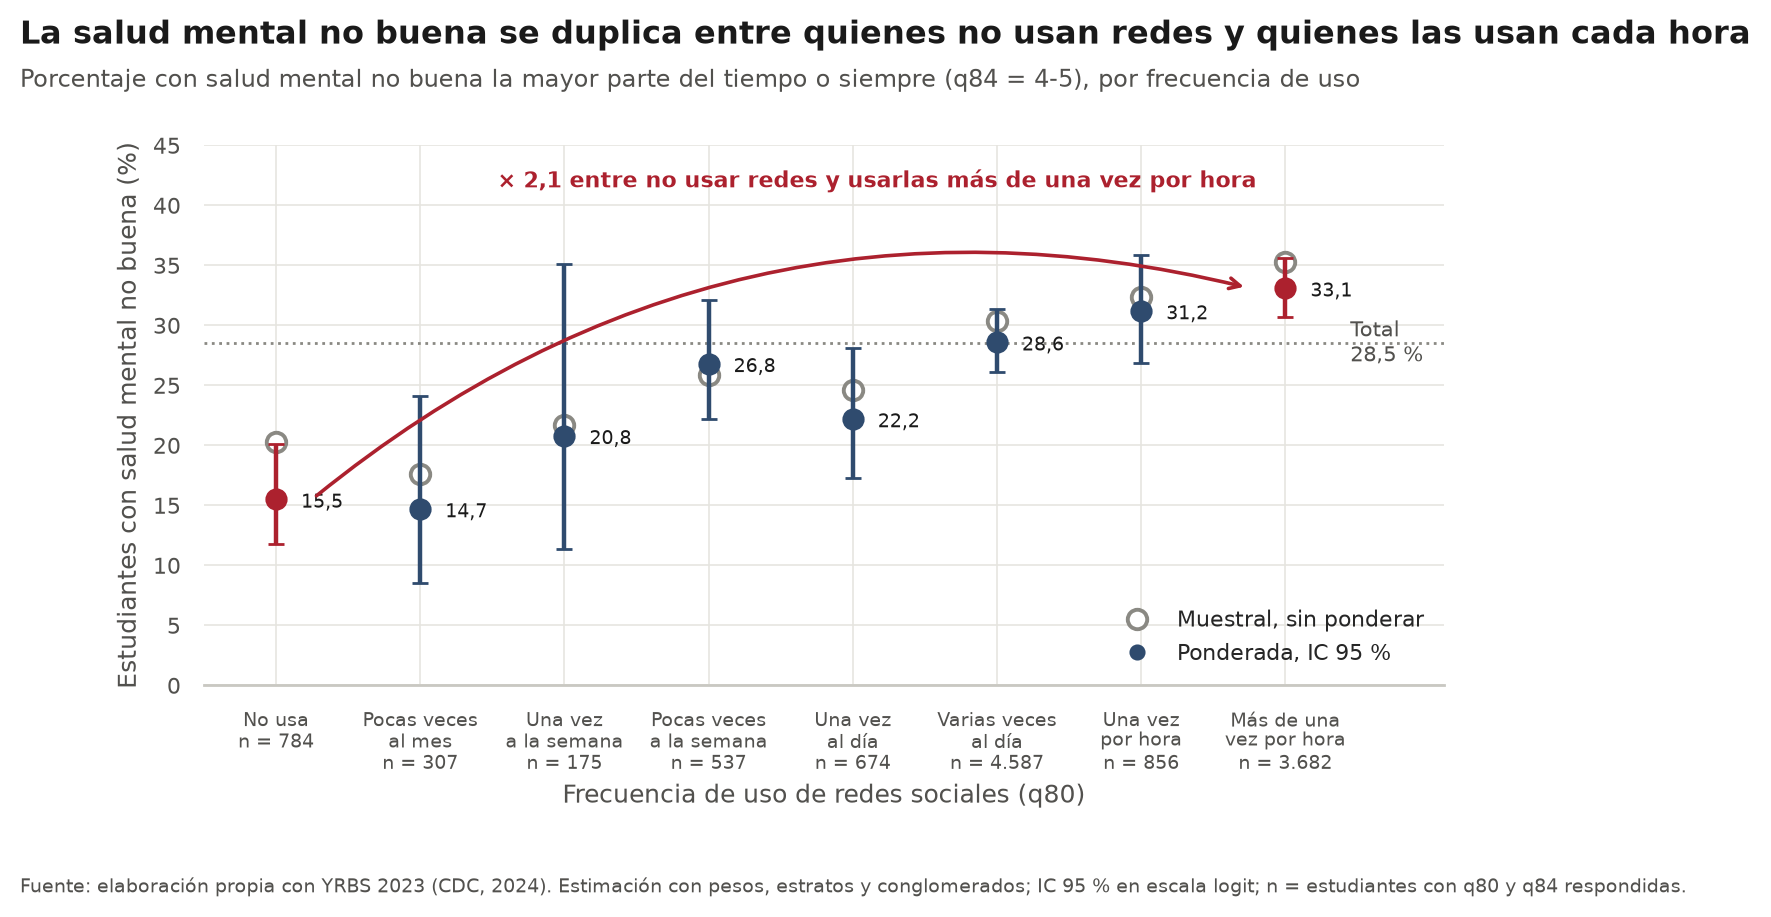

In [16]:
vis.grafico_prevalencia_redes(por_redes, total_sm, RUTA_FIGURAS / "figura1_prevalencia_redes.png")
display(Image(RUTA_FIGURAS / "figura1_prevalencia_redes.png", width=760))

**Figura 1 · OE1 · Acto 1, contexto.**
- *Qué muestra:* la proporción ponderada con salud mental no buena sube de 15,5 % (IC 11,8–20,1)
  entre quienes no usan redes a 33,1 % (IC 30,7–35,6) entre quienes las usan más de una vez por hora.
- *Qué se infiere:* la frecuencia de uso se asocia con más del doble de malestar, y la ponderación
  hace el gradiente más marcado que en la muestra (20,3 % → 35,3 %).
- *Límite:* los niveles 2 y 3 tienen 307 y 175 estudiantes y sus intervalos son anchos; es una
  asociación en una encuesta transversal, no un efecto causal.
- *Aporte al relato:* establece la magnitud (28,5 % en total) y el gradiente que las figuras
  siguientes descomponen.

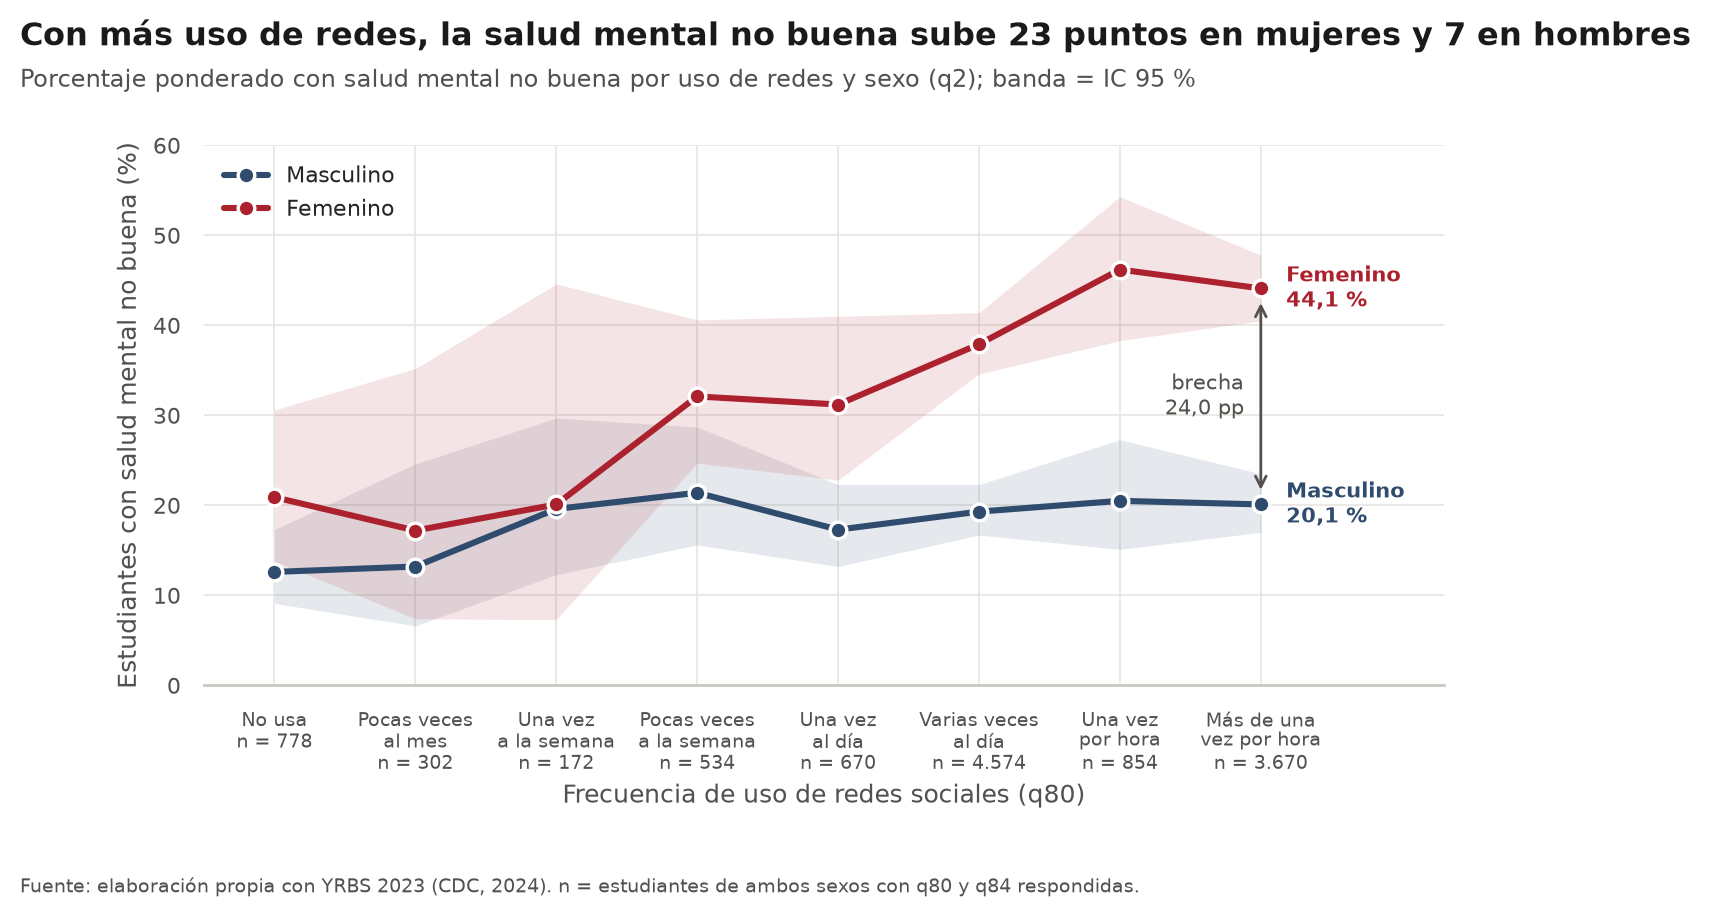

In [17]:
vis.grafico_brecha_sexo(por_redes_sexo, RUTA_FIGURAS / "figura2_brecha_sexo.png")
display(Image(RUTA_FIGURAS / "figura2_brecha_sexo.png", width=760))

**Figura 2 · OE2 · Acto 2, contraste.**
- *Qué muestra:* en el sexo femenino la proporción pasa de 20,9 % a 44,1 % (+23,2 pp); en el
  masculino, de 12,6 % a 20,1 % (+7,5 pp), y la brecha entre sexos crece de 8,3 a 24,0 pp.
- *Qué se infiere:* el gradiente de la Figura 1 se concentra en las estudiantes; el término de
  interacción del modelo lo confirma (OR 1,49; IC 1,11–2,00).
- *Límite:* las bandas se superponen en los niveles de poco uso, donde hay pocos casos por sexo.
- *Aporte al relato:* identifica el grupo que se aparta y donde se concentra el hallazgo.

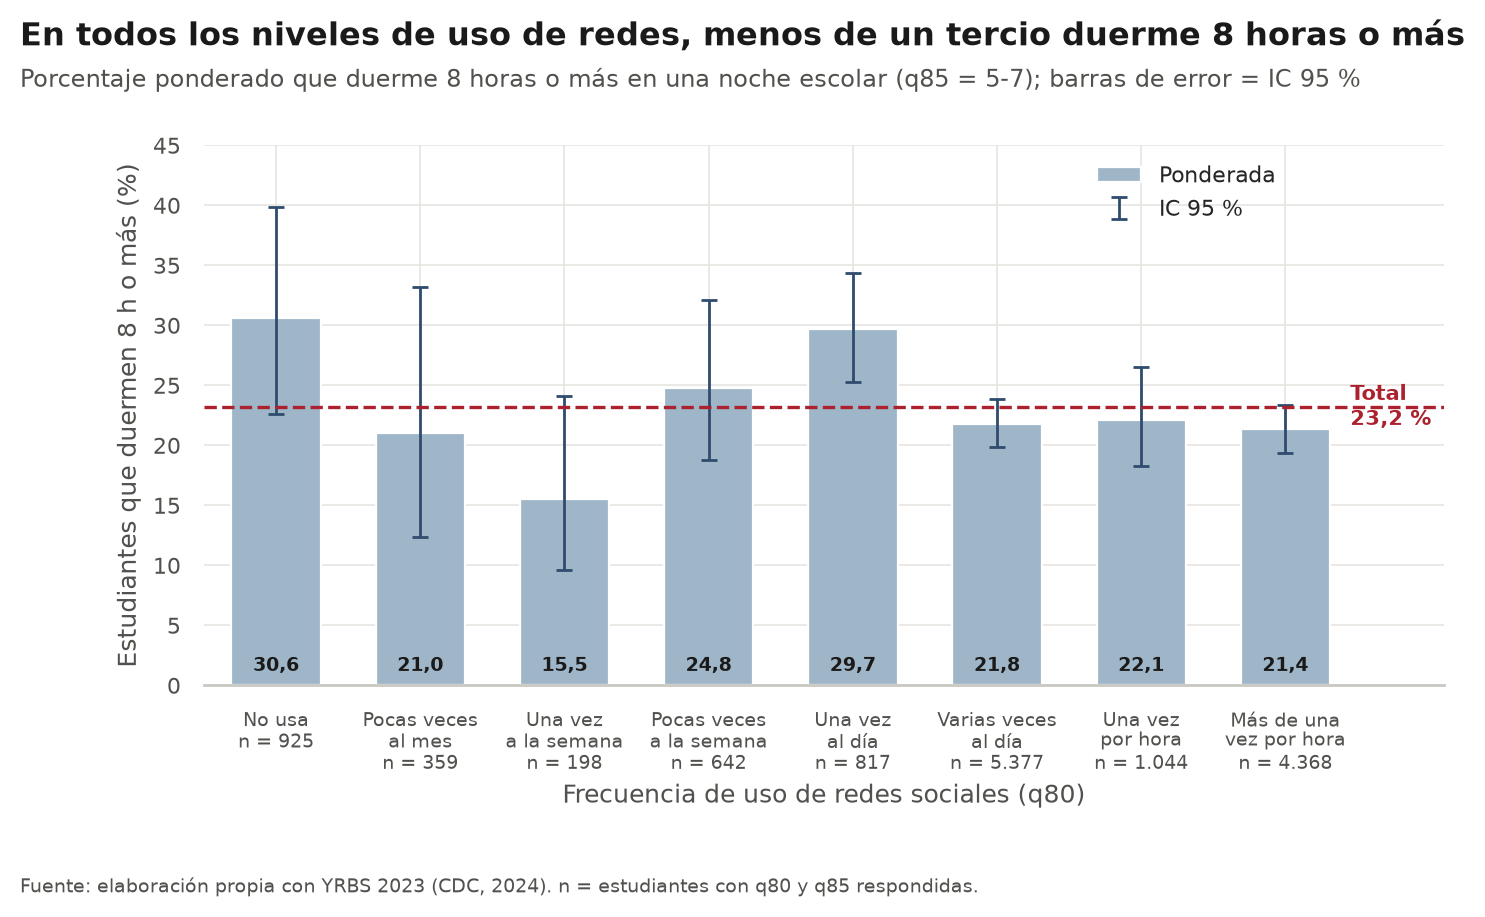

In [18]:
vis.grafico_sueno_redes(sueno_redes, total_sueno, RUTA_FIGURAS / "figura3_sueno_redes.png")
display(Image(RUTA_FIGURAS / "figura3_sueno_redes.png", width=760))

**Figura 3 · OE3 · Acto 3, resolución.**
- *Qué muestra:* solo 23,2 % duerme 8 horas o más; entre quienes no usan redes la cifra es 30,6 %
  (IC 22,6–39,9) y en los tres niveles de mayor uso, 21–22 %.
- *Qué se infiere:* el sueño insuficiente es la norma en todos los niveles, así que no basta para
  explicar el gradiente; el modelo ajustado por sueño mantiene la asociación (OR 2,45).
- *Límite:* los intervalos se solapan y los niveles intermedios no siguen un orden: H3 no es
  concluyente.
- *Aporte al relato:* descarta una explicación alternativa y cierra con la advertencia central,
  asociación y no causalidad.

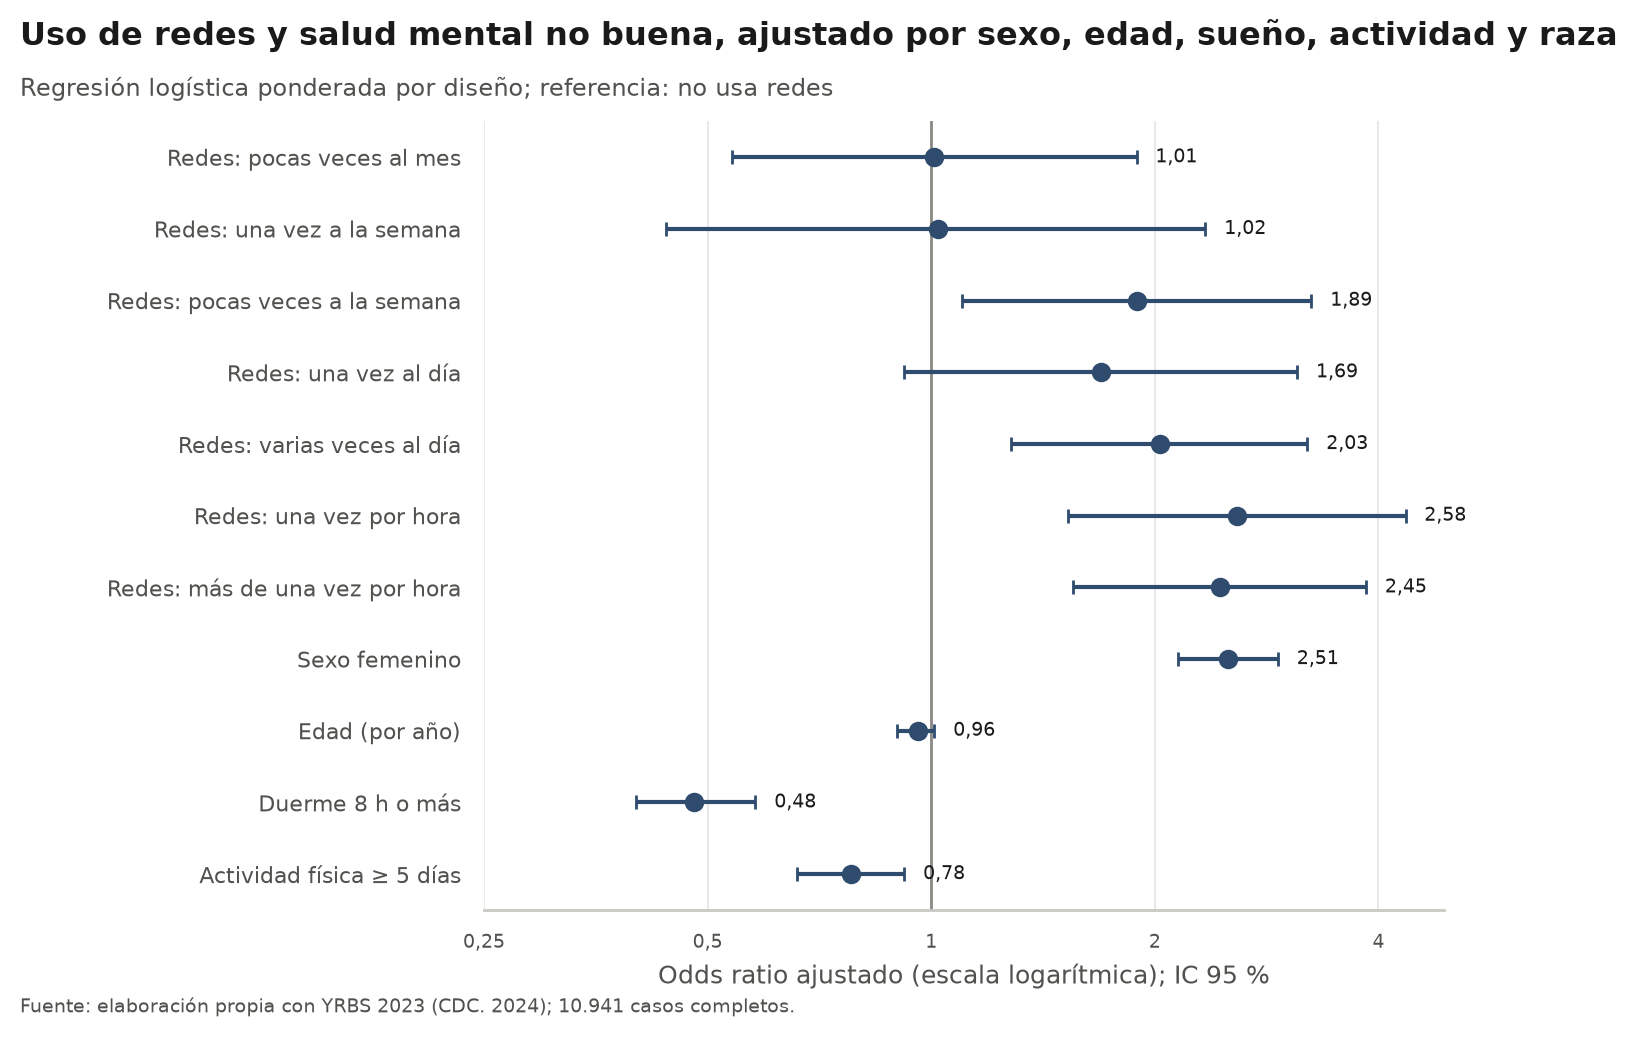

In [19]:
forest = coeficientes[coeficientes["etiqueta"].notna()]
vis.grafico_odds_ratios(forest, modelo.n_usadas_, RUTA_FIGURAS / "figuraA1_odds_ratios.png")
display(Image(RUTA_FIGURAS / "figuraA1_odds_ratios.png", width=760))

## 9. Eficiencia y optimización con `timeit`

**Qué hace.** F3 midió con `perf_counter`; F4 usa el instrumento formal `timeit`
(`Timer.autorange` + `repeat`, mínimo de 5 repeticiones) y agrega el **orden empírico**: se mide a
varios tamaños y se ajusta la pendiente de log(tiempo) contra log(n).

Tres comparaciones:

1. **Varianza por diseño** (componente nuevo de F4, se ejecuta una vez por cada estimación):
   bucle de Python, `groupby` de pandas y `np.bincount`.
2. **Tabla de contingencia q80 × q84** (F3): `iterrows`, `zip`, `crosstab`, `bincount`.
3. **Búsqueda de 200 identificadores** (F3): lineal O(n), binaria recursiva O(log n), diccionario O(1).

Regla heredada de F3: **antes de medir, todas las versiones deben dar el mismo resultado**
(`medir_timeit` lanza `ValueError` si no).

In [20]:
from rendimiento import curva_crecimiento, medir_timeit, orden_empirico

z = np.random.default_rng(SEMILLA).normal(size=len(datos))
VARIANZA = {"numpy (bincount)": lambda d, v: d.varianza(v),
            "pandas (groupby)": lambda d, v: d.varianza_pandas(v),
            "bucle de Python": lambda d, v: d.varianza_bucle(v)}
eficiencia_varianza = medir_timeit(VARIANZA, diseno, z)
eficiencia_varianza.to_csv(RUTA_RESULTADOS / "eficiencia_varianza_f4.csv", index=False)
eficiencia_varianza

,implementacion,ejecuciones,repeticiones,tiempo_min_ms,tiempo_mediana_ms,memoria_pico_kib,veces_mas_lenta
0,numpy (bincount),5000,5,0.0836,0.0849,5.0,1.0
1,pandas (groupby),200,5,1.0899,1.1015,836.2,13.0
2,bucle de Python,100,5,3.2444,3.3376,6.8,38.8


In [21]:
from busqueda import buscar_binaria_rec, buscar_en_indice, buscar_lineal, construir_indice
from contingencia import contar_bincount, contar_crosstab, contar_iterrows, contar_zip, preparar_pares

rng = np.random.default_rng(SEMILLA)
TAMANOS = [5_000, 10_000, 20_000, 40_000, 80_000, 160_000]


def muestra(n):
    # Filas remuestreadas con reemplazo: solo para medir tamaños mayores que el real
    return datos.iloc[rng.integers(0, len(datos), n)].reset_index(drop=True)


def entrada_varianza(n):
    m = muestra(n)
    return DisenoMuestral(m), rng.normal(size=n)


pares_real = preparar_pares(datos, "redes_sociales_cod", "salud_mental_cod")
def entrada_contingencia(n):
    return pares_real.iloc[rng.integers(0, len(pares_real), n)].reset_index(drop=True), \
        "redes_sociales_cod", "salud_mental_cod"


CONTINGENCIA = {"bincount": contar_bincount, "zip": contar_zip,
                "crosstab": contar_crosstab, "iterrows": contar_iterrows}


def entrada_busqueda(n):
    ids = np.arange(1, n + 1)
    return ids, construir_indice(ids), rng.integers(1, n + 1, 200)


BUSQUEDA = {"diccionario O(1)": lambda ids, idx, q: [buscar_en_indice(idx, x) for x in q],
            "binaria recursiva O(log n)": lambda ids, idx, q: [buscar_binaria_rec(ids, x) for x in q],
            "lineal O(n)": lambda ids, idx, q: [buscar_lineal(ids, x) for x in q]}

curvas = {"varianza por diseño": curva_crecimiento(VARIANZA, entrada_varianza, TAMANOS),
          "contingencia q80 × q84": curva_crecimiento(CONTINGENCIA, entrada_contingencia, TAMANOS),
          "búsqueda de 200 id": curva_crecimiento(BUSQUEDA, entrada_busqueda, TAMANOS)}
orden = pd.concat([orden_empirico(c).assign(problema=p) for p, c in curvas.items()])
tiempos_40k = pd.concat([c[c["n"] == 160_000].assign(problema=p) for p, c in curvas.items()])
orden = orden.merge(tiempos_40k[["problema", "implementacion", "tiempo_min_ms"]],
                    on=["problema", "implementacion"]).rename(columns={"tiempo_min_ms": "ms_con_160000"})
pd.concat([c.assign(problema=p) for p, c in curvas.items()]).to_csv(
    RUTA_RESULTADOS / "crecimiento_f4.csv", index=False)
orden.to_csv(RUTA_RESULTADOS / "orden_empirico_f4.csv", index=False)
orden[["problema", "implementacion", "pendiente_loglog", "pendiente_asintotica", "ms_con_160000"]]

,problema,implementacion,pendiente_loglog,pendiente_asintotica,ms_con_160000
0,varianza por diseño,numpy (bincount),0.74,0.98,0.2595
1,varianza por diseño,bucle de Python,0.99,1.02,26.2574
2,varianza por diseño,pandas (groupby),0.31,0.50,2.5622
3,contingencia q80 × q84,bincount,0.83,1.15,0.8161
4,contingencia q80 × q84,zip,0.98,0.99,25.4305
5,contingencia q80 × q84,crosstab,0.21,0.39,9.5672
6,contingencia q80 × q84,iterrows,1.00,1.00,2140.0207
7,búsqueda de 200 id,diccionario O(1),0.02,0.01,0.0224
8,búsqueda de 200 id,binaria recursiva O(log n),0.11,0.10,0.7261
9,búsqueda de 200 id,lineal O(n),0.98,0.96,868.3802


In [22]:
from rendimiento import punto_de_cruce

# Las versiones con costo fijo alto (groupby, crosstab) pierden frente a un bucle con pocos datos
cruces = pd.DataFrame([
    {"problema": "varianza por diseño", "comparacion": "groupby frente a bucle de Python",
     "n_de_cruce": punto_de_cruce(curvas["varianza por diseño"], "pandas (groupby)", "bucle de Python")},
    {"problema": "contingencia q80 × q84", "comparacion": "crosstab frente a zip",
     "n_de_cruce": punto_de_cruce(curvas["contingencia q80 × q84"], "crosstab", "zip")},
]).round(0)
cruces.to_csv(RUTA_RESULTADOS / "puntos_de_cruce_f4.csv", index=False)
cruces

,problema,comparacion,n_de_cruce
0,varianza por diseño,groupby frente a bucle de Python,5268.0
1,contingencia q80 × q84,crosstab frente a zip,32628.0


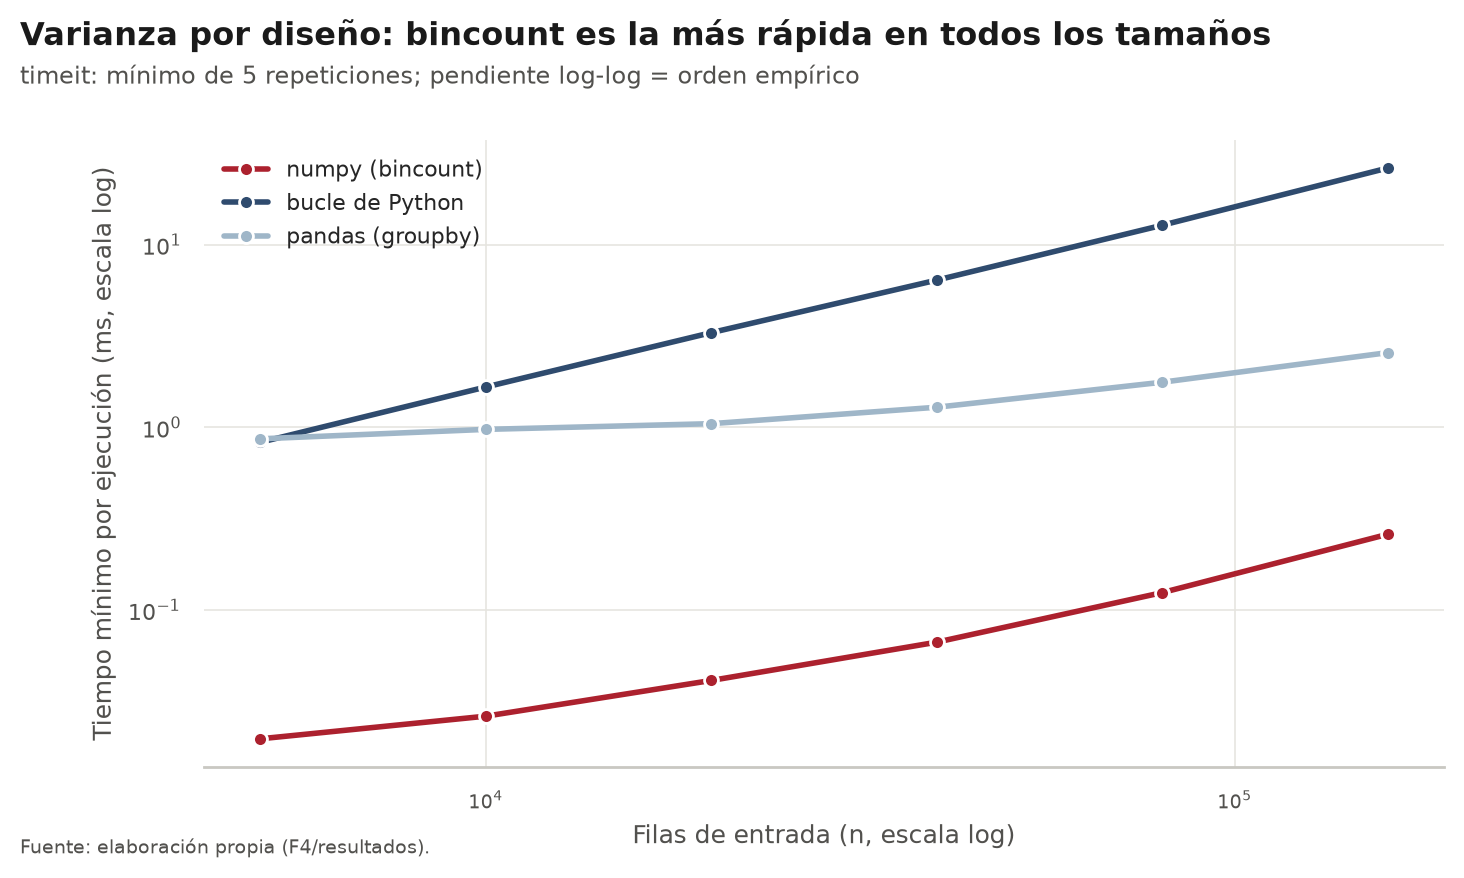

In [23]:
vis.grafico_crecimiento(curvas["varianza por diseño"], RUTA_FIGURAS / "figuraA2_crecimiento_varianza.png",
                        titulo="Varianza por diseño: bincount es la más rápida en todos los tamaños")
display(Image(RUTA_FIGURAS / "figuraA2_crecimiento_varianza.png", width=760))

**Interpretación.**

- **Varianza por diseño.** Con las 20.103 filas reales, `bincount` es ≈ 13 veces más rápida que
  `groupby` y ≈ 39 veces más que el bucle (tabla `eficiencia_varianza_f4.csv`), y usa ≈ 170 veces
  menos memoria pico que `groupby`. Las tres son O(n): el bucle muestra pendiente ≈ 1 en todo el
  rango y `bincount` llega a ≈ 1 en los tamaños grandes (pendiente asintótica); en `groupby` la
  pendiente sigue baja porque hasta 160.000 filas domina su costo fijo (construir índices y
  objetos), no el trabajo por fila. Se adopta `bincount` (`DisenoMuestral.varianza`), que además
  acepta una matriz n × k, necesaria para el sándwich del modelo. **Espacio:** O(G·k) adicional,
  con G = 89 conglomerados.
- **Contingencia.** Confirma la decisión F3.4 con otro instrumento: `iterrows` y `zip` son lineales
  (pendiente 1,0) y `iterrows` tarda más de 2 s con 160.000 filas porque crea una Serie por fila;
  `bincount` es lineal con una constante miles de veces menor. `crosstab` tiene alto costo fijo.
- **Búsqueda.** La lineal tiene pendiente ≈ 1 (recorre el arreglo); la binaria ≈ 0,1, como predice
  O(log n), y el diccionario ≈ 0, O(1). El diccionario gasta O(n) de memoria para el índice
  (≈ 11 veces más, F3.22): conviene porque el proyecto consulta muchas veces.
- **Costo fijo y punto de cruce.** Con pocos datos, las versiones de pandas pierden: `groupby`
  solo supera al bucle desde ≈ 5.300 filas, y `crosstab` es más lento que `zip` por debajo de
  ≈ 32.600 filas, justo el rango de los 11.602 pares del proyecto (tabla `puntos_de_cruce_f4.csv`).
  Por eso la elección no es «vectorizar siempre», sino `bincount`, que gana en todos los tamaños.
- **Lectura de los números.** Los milisegundos dependen del equipo; lo reproducible son las
  pendientes y las razones (bitácora F3.8).

## 10. Validación técnica: pruebas automatizadas

**Qué hace.** Ejecuta con `pytest` la batería de `tests/` (36 pruebas): casos normales, límite y
excepciones de F4 y pruebas de regresión del código de F1–F3 (el pipeline reproduce F2, las cuatro
contingencias coinciden, las tres búsquedas coinciden, el árbol recursivo coincide con `groupby`).

**Por qué pruebas de regresión:** el 28-09-2026 un commit eliminó siete módulos de `src/` y
`F3/src/` y el notebook de F3 dejó de ejecutarse sin que nadie lo notara (bitácora F4.2). Con estas
pruebas, un borrado así falla en segundos.

In [24]:
from verificacion import ejecutar_pruebas

pruebas = ejecutar_pruebas(RAIZ)
(RUTA_RESULTADOS / "pruebas_pytest_f4.txt").write_text(pruebas["salida"], encoding="utf-8")
print(pruebas["salida"])
assert pruebas["codigo_salida"] == 0, "Hay pruebas fallidas"

....................................                                     [100%]
36 passed in 9.62s



In [25]:
# Casos límite y excepciones, ejecutados aquí para dejar evidencia visible en el notebook
casos = []
def caso(descripcion, funcion, esperado):
    try:
        funcion()
        obtenido = "sin excepción"
    except Exception as error:                       # se registra el tipo de la excepción
        obtenido = type(error).__name__
    casos.append({"caso": descripcion, "esperado": esperado, "obtenido": obtenido,
                  "ok": obtenido == esperado})

caso("Diseño sin la columna psu", lambda: DisenoMuestral(datos.drop(columns="psu")), "KeyError")
caso("Un peso igual a cero", lambda: DisenoMuestral(datos.assign(peso_muestral=0.0)), "ValueError")
caso("Desenlace no binario (q84 1-5)", lambda: prevalencia.estimar(datos, "salud_mental_cod"), "ValueError")
caso("DataFrame distinto al del diseño", lambda: prevalencia.estimar(datos.head(10), "salud_mental_mala"), "ValueError")
caso("Grupo inexistente", lambda: prevalencia.estimar(datos, "salud_mental_mala", por="no_existe"), "KeyError")
caso("Modelo sin matriz X", lambda: modelo.estimar(datos, "salud_mental_mala"), "ValueError")
caso("Nivel de confianza 1,5", lambda: diseno.t_critico(1.5), "ValueError")
caso("timeit con resultados distintos", lambda: medir_timeit({"a": lambda: 1, "b": lambda: 2}), "ValueError")
caso("Figura con tabla incompleta", lambda: vis.grafico_sueno_redes(pd.DataFrame({"x": [1]}), 20), "KeyError")
caso("Dominio vacío (caso límite: no falla)",
     lambda: prevalencia.estimar_dominio(datos["salud_mental_mala"].to_numpy(float),
                                         np.zeros(len(datos), bool)), "sin excepción")
tabla_casos = pd.DataFrame(casos)
tabla_casos.to_csv(RUTA_RESULTADOS / "casos_limite_f4.csv", index=False)
assert tabla_casos["ok"].all()
tabla_casos

,caso,esperado,obtenido,ok
0,Diseño sin la columna psu,KeyError,KeyError,True
1,Un peso igual a cero,ValueError,ValueError,True
2,Desenlace no binario (q84 1-5),ValueError,ValueError,True
3,DataFrame distinto al del diseño,ValueError,ValueError,True
4,Grupo inexistente,KeyError,KeyError,True
5,Modelo sin matriz X,ValueError,ValueError,True
6,"Nivel de confianza 1,5",ValueError,ValueError,True
7,timeit con resultados distintos,ValueError,ValueError,True
8,Figura con tabla incompleta,KeyError,KeyError,True
9,Dominio vacío (caso límite: no falla),sin excepción,sin excepción,True


## 11. Reproducibilidad de inicio a fin (F1 → F4)

**Qué hace.** Copia el repositorio a una carpeta temporal y ejecuta allí, de principio a fin, los
notebooks de F1, F2 y F3 con `nbclient`. En la copia, los CSV versionados no se sobrescriben. Junto
con este notebook, cubre las cuatro fases.

In [26]:
from verificacion import ejecutar_notebooks

NOTEBOOKS = ["F1/notebooks/S1_F1_Definicion.ipynb",
             "F2/notebooks/S1_F2_Preprocesamiento.ipynb",
             "F3/notebooks/S2_F3_NucleoAlgoritmico_POO_Grupo8.ipynb"]
if EJECUTAR_VERIFICACION_COMPLETA:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ejecucion = ejecutar_notebooks(RAIZ, NOTEBOOKS)
    ejecucion.to_csv(RUTA_RESULTADOS / "verificacion_ejecucion_f4.csv", index=False)
    assert (ejecucion["estado"] == "OK").all(), ejecucion
else:
    ejecucion = pd.read_csv(RUTA_RESULTADOS / "verificacion_ejecucion_f4.csv")
ejecucion

,notebook,estado,celdas_codigo,segundos,detalle
0,F1/notebooks/S1_F1_Definicion.ipynb,OK,22,1.4,
1,F2/notebooks/S1_F2_Preprocesamiento.ipynb,OK,30,3.0,
2,F3/notebooks/S2_F3_NucleoAlgoritmico_POO_Grupo...,OK,54,28.6,


## 12. Arquitectura generada desde el código

**Qué hace.** Construye la tabla de componentes de F4 **leyendo el código** con `inspect`: módulo,
componente, tipo, clase base y primera línea del docstring. Así la documentación no puede
contradecir al repositorio. Los diagramas de flujo, componentes, secuencia y datos están en
`docs/arquitectura.md` y las decisiones de arquitectura en `docs/adr/`.

```
src/procesamiento.py  ─►  F3/src/ (pipeline POO, núcleo analítico)  ─►  F4/src/ (diseño muestral,
constantes del codebook   transformadores · fabrica · segmentacion       rendimiento, figuras,
                          contingencia · busqueda · medicion             verificación)  ─►  notebook F4
```

In [27]:
import inspect

import encuesta, rendimiento, verificacion

filas = []
for modulo in (encuesta, rendimiento, vis, verificacion):
    for nombre, objeto in inspect.getmembers(modulo, lambda o: inspect.isclass(o) or inspect.isfunction(o)):
        if objeto.__module__ != modulo.__name__ or nombre.startswith("_"):
            continue
        doc = (inspect.getdoc(objeto) or "").splitlines()
        filas.append({"modulo": f"F4/src/{modulo.__name__}.py", "componente": nombre,
                      "tipo": "clase" if inspect.isclass(objeto) else "función",
                      "hereda_de": ", ".join(b.__name__ for b in objeto.__bases__ if b is not object)
                                   if inspect.isclass(objeto) else "",
                      "responsabilidad": doc[0] if doc else ""})
arquitectura = pd.DataFrame(filas)
arquitectura.to_csv(RUTA_RESULTADOS / "arquitectura_f4.csv", index=False)
clases_en_notebook = [n for n, o in globals().items() if inspect.isclass(o) and o.__module__ == "__main__"]
print(f"{len(arquitectura)} componentes en F4/src · clases definidas en este notebook: {len(clases_en_notebook)}")
arquitectura

20 componentes en F4/src · clases definidas en este notebook: 0


,modulo,componente,tipo,hereda_de,responsabilidad
0,F4/src/encuesta.py,ArbolPrevalenciaPonderada,clase,ArbolPrevalencia,ArbolPrevalencia (F3) + estimación ponderada e...
1,F4/src/encuesta.py,DisenoMuestral,clase,,"Pesos, estratos y conglomerados (PSU) de una e..."
2,F4/src/encuesta.py,EstimadorEncuesta,clase,ABC,Base de todo estimador por diseño: recibe el d...
3,F4/src/encuesta.py,PrevalenciaPonderada,clase,EstimadorEncuesta,"Proporción ponderada de un indicador 0/1, tota..."
4,F4/src/encuesta.py,RegresionLogisticaPonderada,clase,EstimadorEncuesta,Regresión logística ponderada con errores está...
5,F4/src/rendimiento.py,curva_crecimiento,función,,Mide todas las implementaciones a varios tamaños.
6,F4/src/rendimiento.py,medir_timeit,función,,Mide cada implementación con timeit y memoria ...
7,F4/src/rendimiento.py,orden_empirico,función,,Pendiente de log(tiempo) contra log(n) por imp...
8,F4/src/rendimiento.py,punto_de_cruce,función,,Tamaño n desde el cual `rapida_en_grande` supe...
9,F4/src/visualizacion.py,estilo,función,,Tema común del curso: whitegrid de seaborn y t...


## 13. Comparación con fases previas, registro y reflexión

| Aspecto | F1–F2 | F3 | F4 (este notebook) |
|---|---|---|---|
| Alcance de las cifras | Muestra (20.103), sin ponderar | Muestra, sin ponderar | **Población** de estudiantes de EE. UU. (pesos, estratos, conglomerados) |
| Salud mental no buena, no usa → >1/hora | — | 20,3 % → 35,3 % | **15,5 % → 33,1 %** (IC 95 %) |
| Validación | `assert` internos | Pipeline = CSV de F2 | + **cifras oficiales del CDC** reproducidas; 36 pruebas `pytest` |
| Medición | — | `perf_counter`, `tracemalloc` | + **`timeit`** y orden empírico (pendiente log-log) |
| Código | 7 funciones (`src/`) | 8 clases + núcleo (`F3/src/`) | + jerarquía `EstimadorEncuesta`, herencia del árbol de F3 |
| Reproducibilidad | `requirements.txt` | Notebook sin clases propias | + ejecución verificada de F1–F3 en copia limpia |

**Reflexión técnica del grupo.**

- *Eficiencia:* la vectorización con `bincount` resolvió los dos cálculos de conteo del proyecto
  (contingencia en F3, varianza por diseño en F4). La lección que se repite es que el orden de
  complejidad no basta: tres versiones O(n) difieren en órdenes de magnitud por la constante.
- *Escalabilidad:* las estimaciones son O(n) por dominio; un árbol de segmentos ponderado con muchos
  niveles haría O(nodos · n). Si el proyecto creciera a varios años del YRBS, el siguiente paso sería
  calcular los totales por conglomerado una sola vez por dominio (O(G) por nodo) en vez de recorrer n.
- *Diseño:* agregar la ponderación no obligó a modificar F3: se heredó de `ArbolPrevalencia` y se
  reutilizaron `preparar_pares`, `contar_bincount` y la fábrica del pipeline. El costo fue asumir una
  dependencia nueva (`scipy`, solo para el cuantil *t*).
- *Proceso:* el borrado accidental de módulos en GitHub mostró que la reproducibilidad no se declara,
  se prueba: por eso F4 agrega pruebas de regresión y la ejecución automática de F1–F3.

In [28]:
resumen = pd.DataFrame([
    {"resultado": "Validación externa CDC (6 cifras e IC)", "valor": f"{validacion_externa['coincide'].sum()} de 6 coinciden"},
    {"resultado": "Salud mental no buena, total (ponderada)", "valor": f"{total_sm} %"},
    {"resultado": "No usa → más de una vez por hora", "valor": f"{extremos.loc[1, 'pct_ponderado']} % → {extremos.loc[8, 'pct_ponderado']} %"},
    {"resultado": "OR ajustado, más de una vez por hora", "valor": coeficientes.set_index('termino').loc['redes_sociales_cod=8', ['odds_ratio', 'ic_inf', 'ic_sup']].tolist()},
    {"resultado": "Pruebas pytest", "valor": pruebas["resumen"]},
    {"resultado": "Notebooks F1-F3 ejecutados sin error", "valor": f"{(ejecucion['estado'] == 'OK').sum()} de {len(ejecucion)}"},
])
resumen.to_csv(RUTA_RESULTADOS / "resumen_f4.csv", index=False)
print("Archivos generados en F4/resultados:", sorted(p.name for p in RUTA_RESULTADOS.glob("*")))
resumen

Archivos generados en F4/resultados: ['arquitectura_f4.csv', 'casos_limite_f4.csv', 'crecimiento_f4.csv', 'eficiencia_varianza_f4.csv', 'entorno_f4.csv', 'modelo_interaccion_f4.csv', 'modelo_logistico_f4.csv', 'orden_empirico_f4.csv', 'prevalencia_redes_f4.csv', 'prevalencia_redes_sexo_f4.csv', 'pruebas_pytest_f4.txt', 'puntos_de_cruce_f4.csv', 'resumen_f4.csv', 'sueno_redes_f4.csv', 'tabla_visual_f4.csv', 'validacion_externa_cdc_f4.csv', 'verificacion_ejecucion_f4.csv']


,resultado,valor
0,Validación externa CDC (6 cifras e IC),6 de 6 coinciden
1,"Salud mental no buena, total (ponderada)",28.5 %
2,No usa → más de una vez por hora,15.5 % → 33.1 %
3,"OR ajustado, más de una vez por hora","[2.45, 1.55, 3.85]"
4,Pruebas pytest,36 passed in 9.62s
5,Notebooks F1-F3 ejecutados sin error,3 de 3


## 14. Verificación final

Tres comprobaciones de cierre, calculadas desde los archivos del repositorio y no escritas a mano:

1. **Cada objetivo específico tiene su evidencia** (apunte de la Fase 4: una figura que no responde
   un objetivo no va en el informe, y un objetivo sin figura deja el trabajo incompleto).
2. **Huella SHA-256 de los datos**, para comprobar que el archivo del CDC y el conjunto de F2 son los
   mismos que produjeron estos resultados. Se calcula sobre el contenido con fin de línea normalizado
   a `\n`, porque Git en Windows puede guardar los CSV con `\r\n` y la huella debe coincidir en
   cualquier equipo.
3. **Lista de verificación** de la guía de la Sumativa 3, cada punto comprobado con un archivo.

In [29]:
from pathlib import Path
import pandas as pd

RAIZ = next(c for c in [Path.cwd(), *Path.cwd().parents] if (c / ".git").exists())
FIG, RES = RAIZ / "F4/figuras", RAIZ / "F4/resultados"

EVIDENCIA = {  # objetivo específico: (hipótesis, archivo que lo responde)
    "OE1 · proporción según frecuencia de uso": ("H1", FIG / "figura1_prevalencia_redes.png"),
    "OE2 · diferencia entre sexos": ("H2", FIG / "figura2_brecha_sexo.png"),
    "OE3 · sueño según frecuencia de uso": ("H3", FIG / "figura3_sueno_redes.png"),
    "OE4 · asociación ajustada": ("H4", RES / "modelo_logistico_f4.csv"),
    "OE5 · flujo reproducible y validado": ("—", RES / "verificacion_ejecucion_f4.csv"),
}
correspondencia = pd.DataFrame(
    [{"objetivo": o, "hipotesis": h, "evidencia": str(a.relative_to(RAIZ)).replace("\\", "/"),
      "existe": a.exists()} for o, (h, a) in EVIDENCIA.items()])
assert correspondencia["existe"].all(), "Hay objetivos sin evidencia"
print(f"{correspondencia['existe'].sum()} de {len(correspondencia)} objetivos tienen su evidencia.")
correspondencia

5 de 5 objetivos tienen su evidencia.


,objetivo,hipotesis,evidencia,existe
0,OE1 · proporción según frecuencia de uso,H1,F4/figuras/figura1_prevalencia_redes.png,True
1,OE2 · diferencia entre sexos,H2,F4/figuras/figura2_brecha_sexo.png,True
2,OE3 · sueño según frecuencia de uso,H3,F4/figuras/figura3_sueno_redes.png,True
3,OE4 · asociación ajustada,H4,F4/resultados/modelo_logistico_f4.csv,True
4,OE5 · flujo reproducible y validado,—,F4/resultados/verificacion_ejecucion_f4.csv,True


In [30]:
import hashlib


def huella(ruta: Path) -> str:
    # SHA-256 del contenido con fin de línea \n (igual en Windows y Linux); 16 primeros caracteres
    contenido = ruta.read_bytes().replace(b"\r\n", b"\n")
    return hashlib.sha256(contenido).hexdigest()[:16]


ARCHIVOS = {"Original del CDC (F1)": RAIZ / "F1/data/raw/XXH2023_YRBSS_data.csv",
            "Conjunto procesado (F2)": RAIZ / "F2/data/processed/yrbs2023_seleccion_procesada.csv",
            "Dependencias": RAIZ / "requirements.txt"}
huellas = pd.DataFrame([{"archivo": nombre, "ruta": str(r.relative_to(RAIZ)).replace("\\", "/"),
                         "bytes": r.stat().st_size, "sha256_16": huella(r)}
                        for nombre, r in ARCHIVOS.items()])
huellas.to_csv(RES / "huellas_f4.csv", index=False)
huellas

,archivo,ruta,bytes,sha256_16
0,Original del CDC (F1),F1/data/raw/XXH2023_YRBSS_data.csv,5122849,590ada8db8d75ec2
1,Conjunto procesado (F2),F2/data/processed/yrbs2023_seleccion_procesada...,1340575,fd22a62beb53a21c
2,Dependencias,requirements.txt,2134,f1cf03fba5bf9dc9


In [31]:
pruebas_txt = (RES / "pruebas_pytest_f4.txt").read_text(encoding="utf-8")
ejecucion = pd.read_csv(RES / "verificacion_ejecucion_f4.csv")
externa = pd.read_csv(RES / "validacion_externa_cdc_f4.csv")
crecimiento = pd.read_csv(RES / "crecimiento_f4.csv")
eficiencia = pd.read_csv(RES / "eficiencia_varianza_f4.csv")
casos = pd.read_csv(RES / "casos_limite_f4.csv")
arquitectura = pd.read_csv(RES / "arquitectura_f4.csv")
requisitos = (RAIZ / "requirements.txt").read_text(encoding="utf-8")

LISTA = [
    ("Cada objetivo específico tiene su figura o tabla", correspondencia["existe"].all()),
    ("Tres figuras exportadas en F4/figuras", len(list(FIG.glob("figura[123]_*.png"))) == 3),
    ("Cifras del CDC reproducidas (6 de 6)", externa["coincide"].all() and len(externa) == 6),
    ("Pruebas pytest aprobadas, ninguna fallida", "passed" in pruebas_txt and "failed" not in pruebas_txt),
    ("Casos límite y excepciones con el resultado esperado", casos["ok"].all()),
    ("Notebooks F1–F3 ejecutados sin errores", (ejecucion["estado"] == "OK").all()),
    ("timeit medido en tres o más tamaños", crecimiento["n"].nunique() >= 3),
    ("La medición incluye memoria (tracemalloc)", "memoria_pico_kib" in eficiencia.columns),
    ("Dependencias con versión fija", "pandas==" in requisitos and "seaborn==" in requisitos),
    ("Componentes de F4 documentados desde el código", len(arquitectura) > 0),
    ("Huellas de los datos registradas", (RES / "huellas_f4.csv").exists()),
]
lista = pd.DataFrame(LISTA, columns=["comprobacion", "ok"])
lista.to_csv(RES / "lista_verificacion_f4.csv", index=False)
print(f"{lista['ok'].sum()} de {len(lista)} comprobaciones aprobadas.")
assert lista["ok"].all(), lista[~lista["ok"]]
lista

11 de 11 comprobaciones aprobadas.


,comprobacion,ok
0,Cada objetivo específico tiene su figura o tabla,True
1,Tres figuras exportadas en F4/figuras,True
2,Cifras del CDC reproducidas (6 de 6),True
3,"Pruebas pytest aprobadas, ninguna fallida",True
4,Casos límite y excepciones con el resultado es...,True
5,Notebooks F1–F3 ejecutados sin errores,True
6,timeit medido en tres o más tamaños,True
7,La medición incluye memoria (tracemalloc),True
8,Dependencias con versión fija,True
9,Componentes de F4 documentados desde el código,True


## 15. Respuesta a la pregunta de investigación

Las secciones anteriores integran y verifican; esta responde. La pregunta de la Fase 1 fue:
**¿qué relación existe entre los patrones de uso de tecnología y los indicadores de salud mental
autopercibida y horas de sueño, considerando variables sociodemográficas y de actividad física?**

La celda siguiente no escribe las cifras a mano: las lee de los archivos que generaron las
secciones 5 y 6 y decide cada veredicto con una regla explícita (intervalos que no se solapan, o
intervalo del *odds ratio* que excluye el 1).

In [32]:
redes = pd.read_csv(RES / "prevalencia_redes_f4.csv").set_index("redes_sociales_cod")
por_sexo = pd.read_csv(RES / "prevalencia_redes_sexo_f4.csv").set_index(["sexo_cod", "redes_sociales_cod"])
sueno = pd.read_csv(RES / "sueno_redes_f4.csv").set_index("redes_sociales_cod")
ajustado = pd.read_csv(RES / "modelo_logistico_f4.csv").set_index("termino")
interaccion = pd.read_csv(RES / "modelo_interaccion_f4.csv").set_index("termino")


def es(valor: float, decimales: int = 1) -> str:
    # Número con coma decimal, como en el informe
    return f"{valor:.{decimales}f}".replace(".", ",")


NO_USA, CADA_HORA, FEMENINO, MASCULINO = 1, 8, 1, 2
or_redes = ajustado.loc["redes_sociales_cod=8"]
or_inter = interaccion.loc["frecuente_x_femenino"]
sube = {s: por_sexo.loc[(s, CADA_HORA), "pct_ponderado"] - por_sexo.loc[(s, NO_USA), "pct_ponderado"]
        for s in (FEMENINO, MASCULINO)}

veredictos = {  # regla que decide cada hipótesis
    "H1": redes.loc[CADA_HORA, "ic_inf"] > redes.loc[NO_USA, "ic_sup"],     # IC sin solaparse
    "H2": or_inter["ic_inf"] > 1,                                           # interacción distinta de 1
    "H3": sueno.loc[CADA_HORA, "ic_sup"] < sueno.loc[NO_USA, "ic_inf"],     # IC sin solaparse
    "H4": or_redes["ic_inf"] > 1,                                           # OR ajustado distinto de 1
}
respuesta = pd.DataFrame([
    {"parte_de_la_pregunta": "Uso de redes y salud mental", "hipotesis": "H1",
     "evidencia": f"{es(redes.loc[NO_USA, 'pct_ponderado'])} % (no usa) → "
                  f"{es(redes.loc[CADA_HORA, 'pct_ponderado'])} % (más de una vez por hora)"},
    {"parte_de_la_pregunta": "Variables sociodemográficas: sexo", "hipotesis": "H2",
     "evidencia": f"femenino +{es(sube[FEMENINO])} pp, masculino +{es(sube[MASCULINO])} pp; "
                  f"interacción OR {es(or_inter['odds_ratio'], 2)}"},
    {"parte_de_la_pregunta": "Uso de redes y horas de sueño", "hipotesis": "H3",
     "evidencia": f"duerme 8 h o más: {es(sueno.loc[NO_USA, 'pct_ponderado'])} % (no usa) y "
                  f"{es(sueno.loc[CADA_HORA, 'pct_ponderado'])} % (más de una vez por hora)"},
    {"parte_de_la_pregunta": "Ajuste por sexo, edad, raza/etnicidad, sueño y actividad física", "hipotesis": "H4",
     "evidencia": f"OR {es(or_redes['odds_ratio'], 2)} (IC {es(or_redes['ic_inf'], 2)}–{es(or_redes['ic_sup'], 2)})"},
])
respuesta["veredicto"] = respuesta["hipotesis"].map(veredictos).map({True: "Se sostiene", False: "No concluyente"})
respuesta.to_csv(RES / "respuesta_pregunta_f4.csv", index=False)

sostenidas = [h for h, ok in veredictos.items() if ok]
print(f"Se sostienen {', '.join(sostenidas)}; no concluyente: "
      f"{', '.join(h for h in veredictos if h not in sostenidas)}.")
with pd.option_context("display.max_colwidth", 120):
    display(respuesta)

Se sostienen H1, H2, H4; no concluyente: H3.


,parte_de_la_pregunta,hipotesis,evidencia,veredicto
0,Uso de redes y salud mental,H1,"15,5 % (no usa) → 33,1 % (más de una vez por hora)",Se sostiene
1,Variables sociodemográficas: sexo,H2,"femenino +23,2 pp, masculino +7,5 pp; interacción OR 1,49",Se sostiene
2,Uso de redes y horas de sueño,H3,"duerme 8 h o más: 30,6 % (no usa) y 21,4 % (más de una vez por hora)",No concluyente
3,"Ajuste por sexo, edad, raza/etnicidad, sueño y actividad física",H4,"OR 2,45 (IC 1,55–3,85)",Se sostiene


**Respuesta.** Sí existe relación, y se resume en tres hallazgos:

1. **El malestar se duplica con el uso.** La proporción de estudiantes con salud mental no buena pasa
   de 15,5 % entre quienes no usan redes a 33,1 % entre quienes las usan más de una vez por hora, con
   intervalos que no se solapan (H1).
2. **La relación se concentra en las estudiantes.** En el sexo femenino la proporción sube 23,2 puntos
   y en el masculino 7,5; la interacción uso × sexo es significativa (OR 1,49) (H2).
3. **No se explica por el sueño ni por la actividad física.** Al comparar estudiantes del mismo sexo,
   edad, raza/etnicidad, sueño y actividad, usar redes más de una vez por hora se asocia con 2,45
   veces las chances de salud mental no buena (IC 1,55–3,85) (H4).

Sobre las **horas de sueño**, la respuesta es que los datos no alcanzan para afirmar una relación con
el uso de redes (H3): dormir menos de 8 horas es lo habitual en todos los niveles de uso. Duerme 8
horas o más el 30,6 % de quienes no usan redes (IC 22,6–39,9) y el 21,4 % de quienes las usan más de
una vez por hora (IC 19,4–23,4). La diferencia es de 9 puntos, pero los intervalos se solapan: el
grupo que no usa redes es pequeño (n = 925) y su estimación es poco precisa, así que la regla de
decisión no permite sostener H3. El sueño sí se asocia por sí mismo con la salud mental (OR 0,48
para quienes duermen 8 horas o más).

**Alcance de la respuesta.** Es una **asociación, no una causa**: la encuesta mide todo en un mismo
momento y no permite saber si el uso de redes precede al malestar o al revés. `q80` mide frecuencia
de uso, no horas ni tipo de uso, y los resultados describen a estudiantes de enseñanza media de
Estados Unidos en 2023.

### Referencias citadas en este notebook

- Centers for Disease Control and Prevention. (2024). *2023 Youth Risk Behavior Survey data* [Conjunto de datos]. https://www.cdc.gov/yrbs/data/index.html
- Python Software Foundation. (s. f.). *timeit — Measure execution time of small code snippets*. https://docs.python.org/3/library/timeit.html
- Valkenburg, P. M., Meier, A., & Beyens, I. (2022). Social media use and its impact on adolescent mental health: An umbrella review of the evidence. *Current Opinion in Psychology, 44*, 58–68. https://doi.org/10.1016/j.copsyc.2021.08.017
- Verlenden, J. V., Fodeman, A., Wilkins, N., Jones, S. E., Moore, S., Cornett, K., Sims, V., Saelee, R., & Brener, N. D. (2024). Mental health and suicide risk among high school students and protective factors — Youth Risk Behavior Survey, United States, 2023. *MMWR Supplements, 73*(4), 79–86. https://doi.org/10.15585/mmwr.su7304a9
- Young, E., McCain, J. L., Mercado, M. C., Ballesteros, M. F., Moore, S., Licitis, L., Stinson, J., Jones, S. E., & Wilkins, N. J. (2024). Frequent social media use and experiences with bullying victimization, persistent feelings of sadness or hopelessness, and suicide risk among high school students — Youth Risk Behavior Survey, United States, 2023. *MMWR Supplements, 73*(4), 23–30. https://doi.org/10.15585/mmwr.su7304a3